# Functional distribution of GDP in Portugal

## Capital, wages, and taxes net of subsidies

This notebook analyses the composition of Portuguese GDP from the income side.

The decomposition used is:

\[
GDP = D.1 + B.2g/B.3g + D.2 - D.3
\]

Where:

- **D.1** represents compensation of employees;
- **B.2g/B.3g** represents gross operating surplus and gross mixed income;
- **D.2 - D.3** represents taxes on production and imports net of subsidies.

The goal is to observe how these components evolve as a share of GDP, with particular attention to the capital income share over time.

## Data sources

The main source is Eurostat, through the `nama_10_gdp` dataset: *Gross domestic product and main components (output, expenditure and income)*.

The data is obtained via DBnomics.

| Component | Eurostat code | DBnomics series |
|---|---:|---|
| GDP at market prices | `B1GQ` | `Eurostat/nama_10_gdp/A.CP_MEUR.B1GQ.PT` |
| Compensation of employees | `D1` | `Eurostat/nama_10_gdp/A.CP_MEUR.D1.PT` |
| Gross operating surplus + gross mixed income | `B2A3G` | `Eurostat/nama_10_gdp/A.CP_MEUR.B2A3G.PT` |
| Taxes net of subsidies | `D2X3` | `Eurostat/nama_10_gdp/A.CP_MEUR.D2X3.PT` |

The unit used is `CP_MEUR`, i.e. current prices in millions of euros.

## Installing dependencies

```bash
pip install pandas matplotlib dbnomics
```

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Final

import matplotlib.pyplot as plt
import pandas as pd
from dbnomics import fetch_series

C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (6.0.0.post1)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


## Configuration

We define the series codes, the analysis period, and the macroeconomic events marked on the charts.

In [2]:
GDP_SERIES: Final[str] = "Eurostat/nama_10_gdp/A.CP_MEUR.B1GQ.PT"
WAGES_SERIES: Final[str] = "Eurostat/nama_10_gdp/A.CP_MEUR.D1.PT"
CAPITAL_INCOME_SERIES: Final[str] = "Eurostat/nama_10_gdp/A.CP_MEUR.B2A3G.PT"
NET_TAXES_SERIES: Final[str] = "Eurostat/nama_10_gdp/A.CP_MEUR.D2X3.PT"

START_YEAR: Final[int] = 1995
MOVING_AVERAGE_WINDOW: Final[int] = 3


@dataclass(frozen=True)
class CrisisEvent:
    """
    Represent a crisis or relevant macroeconomic event.

    Parameters
    ----------
    year : int
        Reference year of the event.
    label : str
        Short label to display on the chart.
    """

    year: int
    label: str


CRISIS_EVENTS: Final[list[CrisisEvent]] = [
    CrisisEvent(2000, "Dot-com"),
    CrisisEvent(2001, "11 Sep"),
    CrisisEvent(2008, "Global financial crisis"),
    CrisisEvent(2011, "Troika / sovereign debt"),
    CrisisEvent(2020, "COVID-19"),
    CrisisEvent(2022, "Energy / Ukraine"),
]

## Fetching the Eurostat series

This function downloads a series from DBnomics and turns it into a simple table with year and value.

In [3]:
def fetch_eurostat_series(series_code: str, value_name: str) -> pd.DataFrame:
    """
    Fetch a Eurostat annual series from DBnomics.

    Parameters
    ----------
    series_code : str
        DBnomics series identifier.
    value_name : str
        Name of the output value column.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns `year` and `value_name`.
    """
    if not isinstance(series_code, str) or not series_code:
        raise TypeError("series_code must be a non-empty string.")

    if not isinstance(value_name, str) or not value_name:
        raise TypeError("value_name must be a non-empty string.")

    raw_df = fetch_series(series_code)

    if not isinstance(raw_df, pd.DataFrame):
        raise TypeError("Expected DBnomics to return a pandas DataFrame.")

    required_columns: set[str] = {"period", "value"}
    missing_columns = required_columns.difference(raw_df.columns)

    if missing_columns:
        raise ValueError(f"Missing expected columns: {missing_columns}")

    clean_df = raw_df.loc[:, ["period", "value"]].copy()
    clean_df["year"] = pd.to_datetime(clean_df["period"]).dt.year
    clean_df = clean_df.loc[:, ["year", "value"]]
    clean_df = clean_df.rename(columns={"value": value_name})
    clean_df = clean_df.dropna(subset=[value_name])
    clean_df = clean_df.sort_values("year").reset_index(drop=True)

    return clean_df

## Building the analysis base

Here we join the four main series: GDP, wages, capital income, and taxes net of subsidies. We then compute each component as a share of GDP.

In [4]:
def build_income_distribution_dataframe(start_year: int = START_YEAR) -> pd.DataFrame:
    """
    Build the income-side GDP decomposition for Portugal.

    Parameters
    ----------
    start_year : int
        First year to keep in the final dataset.

    Returns
    -------
    pd.DataFrame
        Annual DataFrame with levels and shares of GDP.
    """
    if not isinstance(start_year, int):
        raise TypeError("start_year must be an integer.")

    gdp_df = fetch_eurostat_series(GDP_SERIES, "gdp")
    wages_df = fetch_eurostat_series(WAGES_SERIES, "wages")
    capital_df = fetch_eurostat_series(CAPITAL_INCOME_SERIES, "capital_income")
    taxes_df = fetch_eurostat_series(NET_TAXES_SERIES, "net_taxes_less_subsidies")

    df = (
        gdp_df
        .merge(wages_df, on="year", how="inner")
        .merge(capital_df, on="year", how="inner")
        .merge(taxes_df, on="year", how="inner")
    )

    df = df[df["year"] >= start_year].copy()
    df = df.sort_values("year").reset_index(drop=True)

    df["wages_share_pct"] = 100.0 * df["wages"] / df["gdp"]
    df["capital_income_share_pct"] = 100.0 * df["capital_income"] / df["gdp"]
    df["net_taxes_share_pct"] = 100.0 * df["net_taxes_less_subsidies"] / df["gdp"]

    df["components_sum"] = df["wages"] + df["capital_income"] + df["net_taxes_less_subsidies"]
    df["components_sum_share_pct"] = df["wages_share_pct"] + df["capital_income_share_pct"] + df["net_taxes_share_pct"]
    df["identity_gap_million_eur"] = df["gdp"] - df["components_sum"]
    df["identity_gap_pct_gdp"] = 100.0 * df["identity_gap_million_eur"] / df["gdp"]

    df["wages_share_ma3"] = df["wages_share_pct"].rolling(window=MOVING_AVERAGE_WINDOW, min_periods=1).mean()
    df["capital_income_share_ma3"] = df["capital_income_share_pct"].rolling(window=MOVING_AVERAGE_WINDOW, min_periods=1).mean()
    df["net_taxes_share_ma3"] = df["net_taxes_share_pct"].rolling(window=MOVING_AVERAGE_WINDOW, min_periods=1).mean()

    return df


df = build_income_distribution_dataframe()
df.head()

,year,gdp,wages,capital_income,net_taxes_less_subsidies,wages_share_pct,capital_income_share_pct,net_taxes_share_pct,components_sum,components_sum_share_pct,identity_gap_million_eur,identity_gap_pct_gdp,wages_share_ma3,capital_income_share_ma3,net_taxes_share_ma3
0,1995,91015.8,42592.0,38124.3,10299.6,46.796271,41.887562,11.316277,91015.9,100.000110,-0.1,-0.000110,46.796271,41.887562,11.316277
1,1996,96626.8,45839.5,39924.1,10863.1,47.439737,41.317833,11.242326,96626.7,99.999897,0.1,0.000103,47.118004,41.602698,11.279302
2,1997,103306.6,49059.8,42667.9,11578.9,47.489512,41.302201,11.208287,103306.6,100.000000,0.0,0.000000,47.241840,41.502532,11.255630
3,1998,110683.7,52787.6,45043.5,12852.7,47.692298,40.695694,11.612098,110683.8,100.000090,-0.1,-0.000090,47.540516,41.105243,11.354237
4,1999,119603.3,57079.5,48497.7,14026.1,47.724018,40.548798,11.727185,119603.3,100.000000,0.0,0.000000,47.635276,40.848898,11.515857


## Checking the accounting identity

The sum of the three components should be very close to 100% of GDP. Small differences can arise from rounding, statistical revisions, or publication details.

In [5]:
identity_check = df.loc[:, ["year", "components_sum_share_pct", "identity_gap_pct_gdp", "identity_gap_million_eur"]].copy()
identity_check["components_sum_share_pct"] = identity_check["components_sum_share_pct"].round(4)
identity_check["identity_gap_pct_gdp"] = identity_check["identity_gap_pct_gdp"].round(6)
identity_check["identity_gap_million_eur"] = identity_check["identity_gap_million_eur"].round(2)
identity_check.tail(10)

,year,components_sum_share_pct,identity_gap_pct_gdp,identity_gap_million_eur
20,2015,100.0001,-0.000056,-0.1
21,2016,100.0000,0.000000,0.0
22,2017,100.0001,-0.000051,-0.1
23,2018,100.0000,0.000000,0.0
24,2019,100.0000,0.000047,0.1
25,2020,100.0000,0.000000,0.0
26,2021,100.0000,-0.000046,-0.1
27,2022,100.0000,0.000000,0.0
28,2023,100.0000,-0.000037,-0.1
29,2024,100.0000,0.000000,0.0


## Working table

This table shows the three components as a share of GDP.

In [6]:
shares_table = df.loc[:, ["year", "wages_share_pct", "capital_income_share_pct", "net_taxes_share_pct"]].copy()
shares_table = shares_table.rename(columns={
    "wages_share_pct": "wages_pct_gdp",
    "capital_income_share_pct": "capital_pct_gdp",
    "net_taxes_share_pct": "net_taxes_pct_gdp",
})

for column in ["wages_pct_gdp", "capital_pct_gdp", "net_taxes_pct_gdp"]:
    shares_table[column] = shares_table[column].round(2)

shares_table.tail(10)

,year,wages_pct_gdp,capital_pct_gdp,net_taxes_pct_gdp
20,2015,43.84,42.78,13.38
21,2016,43.62,42.89,13.49
22,2017,43.94,42.13,13.93
23,2018,44.65,41.28,14.07
24,2019,45.20,40.78,14.01
25,2020,48.20,39.75,12.05
26,2021,47.93,39.79,12.28
27,2022,46.57,40.21,13.22
28,2023,46.99,39.82,13.18
29,2024,47.67,39.23,13.10


## Helper function to annotate crises

This function adds vertical lines to the charts for relevant events.

In [7]:
def annotate_crises(ax: plt.Axes, df: pd.DataFrame, events: list[CrisisEvent], y_position: float | None = None) -> None:
    """
    Annotate selected macroeconomic events on a Matplotlib chart.

    Parameters
    ----------
    ax : plt.Axes
        Matplotlib axes where annotations will be added.
    df : pd.DataFrame
        Dataset used in the chart.
    events : list[CrisisEvent]
        Events to annotate.
    y_position : float | None
        Optional fixed y coordinate for labels.
    """
    if "year" not in df.columns:
        raise ValueError("df must contain a 'year' column.")

    year_min = int(df["year"].min())
    year_max = int(df["year"].max())

    if y_position is None:
        share_columns = [column for column in df.columns if column.endswith("_share_pct")]
        y_position = float(df[share_columns].max().max()) if share_columns else 100.0

    for event in events:
        if year_min <= event.year <= year_max:
            ax.axvline(event.year, linestyle="--", linewidth=1, alpha=0.7)
            ax.text(event.year + 0.1, y_position, event.label, rotation=90, verticalalignment="top", fontsize=9)

## Chart 1 — Functional distribution of GDP

This chart shows the share of GDP associated with wages, capital income, and taxes net of subsidies.

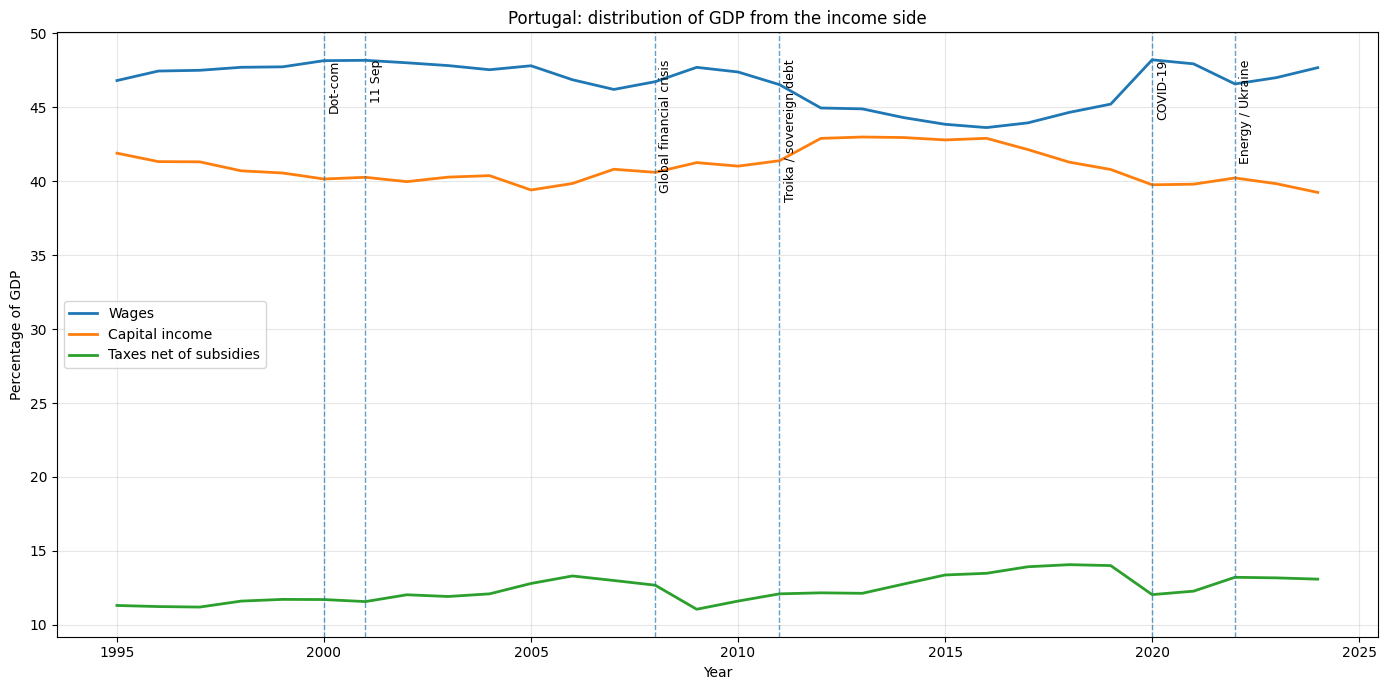

In [8]:
def plot_income_distribution(df: pd.DataFrame) -> None:
    """
    Plot wages, capital income, and net taxes as shares of GDP.

    Parameters
    ----------
    df : pd.DataFrame
        Income distribution dataset.
    """
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(df["year"], df["wages_share_pct"], label="Wages", linewidth=2)
    ax.plot(df["year"], df["capital_income_share_pct"], label="Capital income", linewidth=2)
    ax.plot(df["year"], df["net_taxes_share_pct"], label="Taxes net of subsidies", linewidth=2)

    y_position = float(max(df["wages_share_pct"].max(), df["capital_income_share_pct"].max(), df["net_taxes_share_pct"].max()))
    annotate_crises(ax, df, CRISIS_EVENTS, y_position=y_position)

    ax.set_title("Portugal: distribution of GDP from the income side")
    ax.set_xlabel("Year")
    ax.set_ylabel("Percentage of GDP")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_income_distribution(df)

## Chart 2 — Smoothed series

The 3-year moving average helps remove short-term noise.

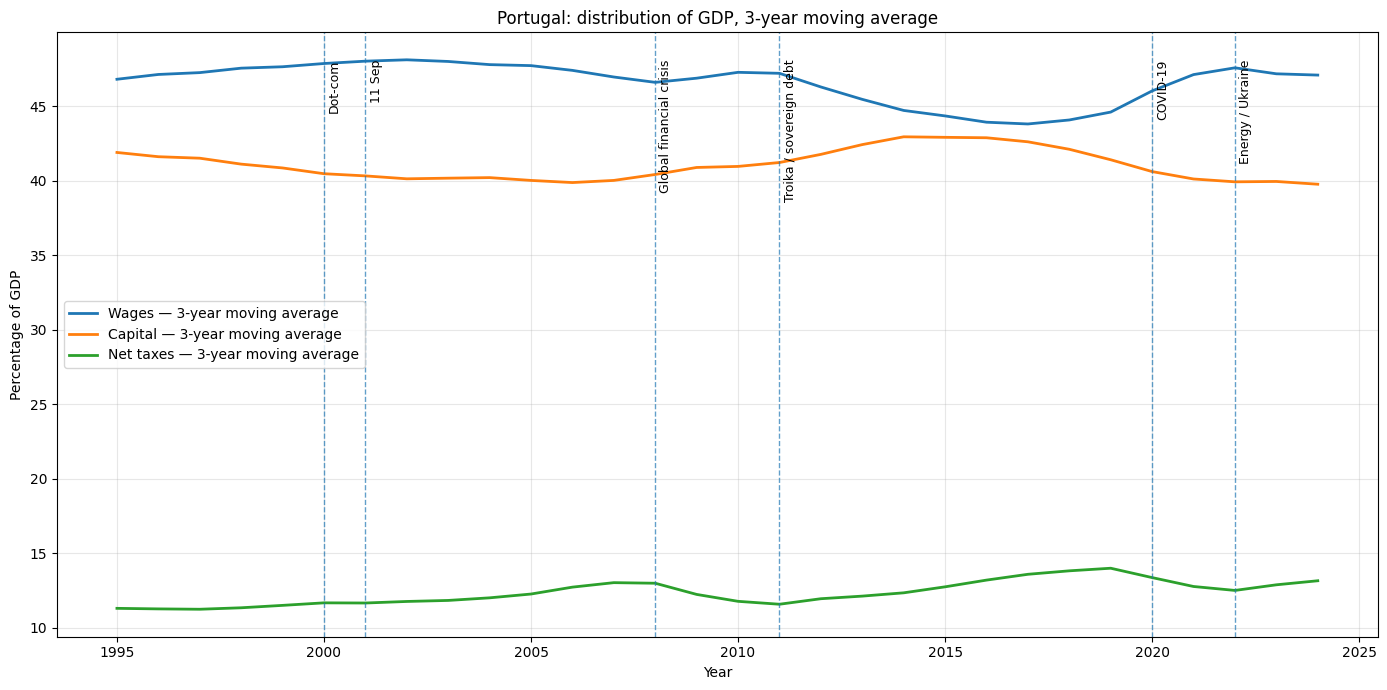

In [9]:
def plot_income_distribution_moving_average(df: pd.DataFrame) -> None:
    """
    Plot moving averages for the income-side GDP components.

    Parameters
    ----------
    df : pd.DataFrame
        Income distribution dataset.
    """
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(df["year"], df["wages_share_ma3"], label="Wages — 3-year moving average", linewidth=2)
    ax.plot(df["year"], df["capital_income_share_ma3"], label="Capital — 3-year moving average", linewidth=2)
    ax.plot(df["year"], df["net_taxes_share_ma3"], label="Net taxes — 3-year moving average", linewidth=2)

    y_position = float(max(df["wages_share_ma3"].max(), df["capital_income_share_ma3"].max(), df["net_taxes_share_ma3"].max()))
    annotate_crises(ax, df, CRISIS_EVENTS, y_position=y_position)

    ax.set_title("Portugal: distribution of GDP, 3-year moving average")
    ax.set_xlabel("Year")
    ax.set_ylabel("Percentage of GDP")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_income_distribution_moving_average(df)

## Chart 3 — Focus on capital income

Here we isolate capital income alone, showing both the annual series and the moving average.

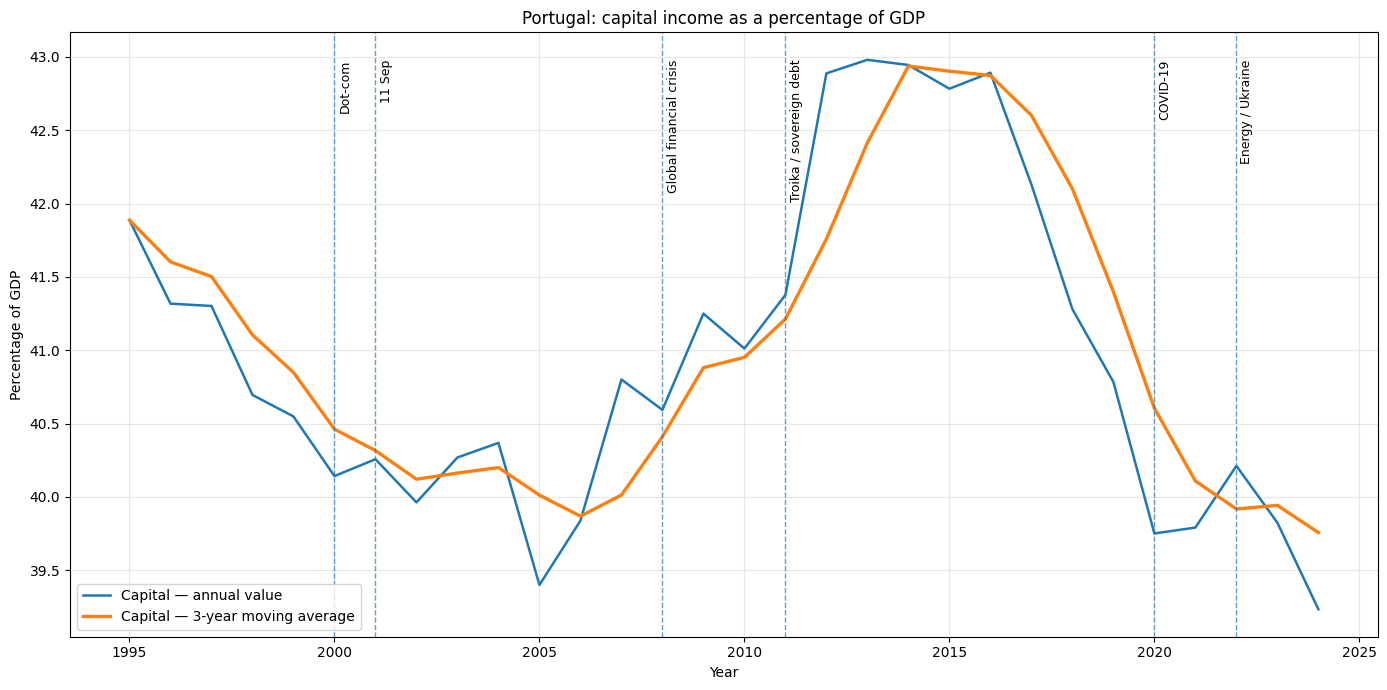

In [10]:
def plot_capital_income_focus(df: pd.DataFrame) -> None:
    """
    Plot capital income share in GDP with a moving average.

    Parameters
    ----------
    df : pd.DataFrame
        Income distribution dataset.
    """
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(df["year"], df["capital_income_share_pct"], label="Capital — annual value", linewidth=1.8)
    ax.plot(df["year"], df["capital_income_share_ma3"], label="Capital — 3-year moving average", linewidth=2.4)

    y_position = float(df["capital_income_share_pct"].max())
    annotate_crises(ax, df, CRISIS_EVENTS, y_position=y_position)

    ax.set_title("Portugal: capital income as a percentage of GDP")
    ax.set_xlabel("Year")
    ax.set_ylabel("Percentage of GDP")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_capital_income_focus(df)

## Chart 4 — Difference between capital and wages

This chart shows:

\[
\text{capital share} - \text{wage share}
\]

Higher values indicate that the capital share moves closer to the wage share, i.e. that the gap between wages and capital narrows.

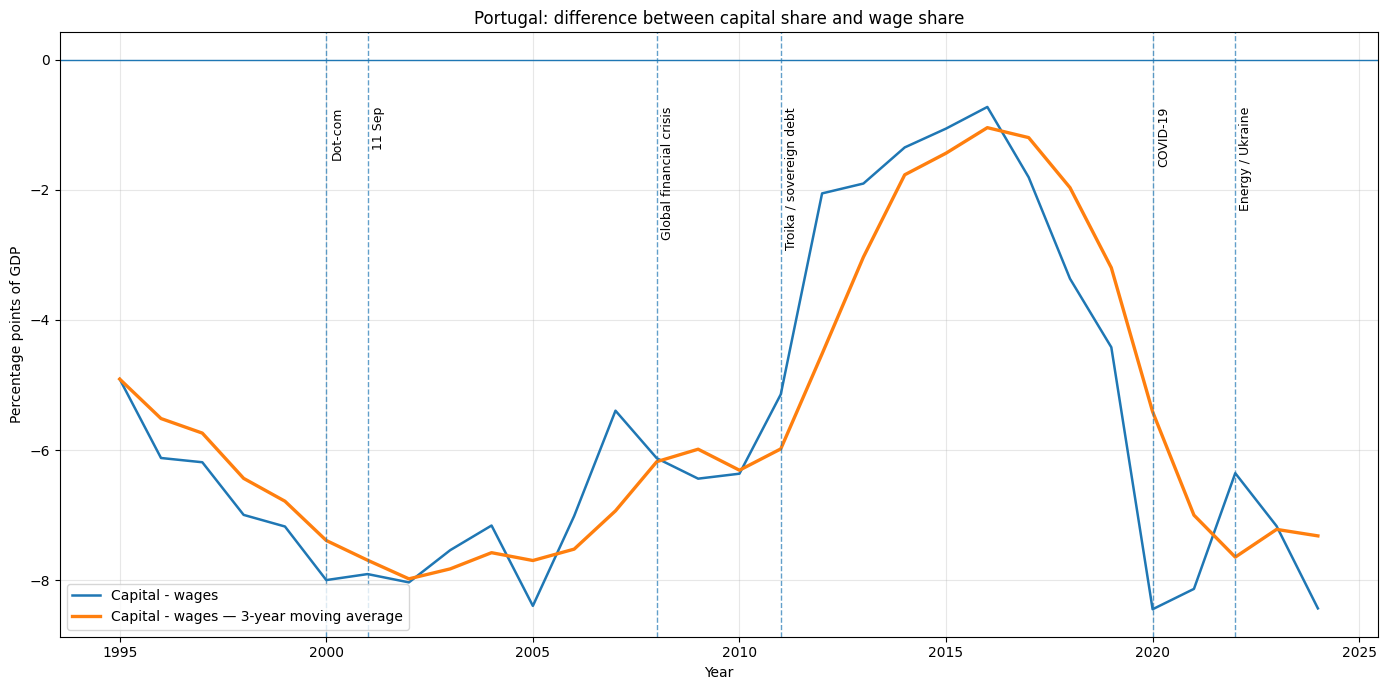

In [11]:
df["capital_minus_wages_pct_points"] = df["capital_income_share_pct"] - df["wages_share_pct"]
df["capital_minus_wages_ma3"] = df["capital_minus_wages_pct_points"].rolling(window=MOVING_AVERAGE_WINDOW, min_periods=1).mean()


def plot_capital_minus_wages(df: pd.DataFrame) -> None:
    """
    Plot the difference between capital income share and wage share.

    Parameters
    ----------
    df : pd.DataFrame
        Income distribution dataset.
    """
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.axhline(0, linewidth=1)
    ax.plot(df["year"], df["capital_minus_wages_pct_points"], label="Capital - wages", linewidth=1.8)
    ax.plot(df["year"], df["capital_minus_wages_ma3"], label="Capital - wages — 3-year moving average", linewidth=2.4)

    y_position = float(df["capital_minus_wages_pct_points"].max())
    annotate_crises(ax, df, CRISIS_EVENTS, y_position=y_position)

    ax.set_title("Portugal: difference between capital share and wage share")
    ax.set_xlabel("Year")
    ax.set_ylabel("Percentage points of GDP")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_capital_minus_wages(df)

## Summary statistics

This cell identifies the first and last year, minimums, maximums, and the cumulative change.

In [12]:
def summarize_share(df: pd.DataFrame, column: str, label: str) -> dict[str, float | int | str]:
    """
    Summarize a GDP share column.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset containing a year column and the target share.
    column : str
        Column to summarize.
    label : str
        Human-readable label.

    Returns
    -------
    dict[str, float | int | str]
        Summary statistics for the selected share.
    """
    if column not in df.columns:
        raise ValueError(f"Column not found: {column}")

    first_idx = df["year"].idxmin()
    last_idx = df["year"].idxmax()
    min_idx = df[column].idxmin()
    max_idx = df[column].idxmax()
    first_value = float(df.loc[first_idx, column])
    last_value = float(df.loc[last_idx, column])

    return {
        "component": label,
        "first_year": int(df.loc[first_idx, "year"]),
        "first_value_pct": round(first_value, 2),
        "last_year": int(df.loc[last_idx, "year"]),
        "last_value_pct": round(last_value, 2),
        "change_pct_points": round(last_value - first_value, 2),
        "min_year": int(df.loc[min_idx, "year"]),
        "min_value_pct": round(float(df.loc[min_idx, column]), 2),
        "max_year": int(df.loc[max_idx, "year"]),
        "max_value_pct": round(float(df.loc[max_idx, column]), 2),
    }


summary = pd.DataFrame([
    summarize_share(df, "wages_share_pct", "Wages"),
    summarize_share(df, "capital_income_share_pct", "Capital income"),
    summarize_share(df, "net_taxes_share_pct", "Taxes net of subsidies"),
])

summary

,component,first_year,first_value_pct,last_year,last_value_pct,change_pct_points,min_year,min_value_pct,max_year,max_value_pct
0,Wages,1995,46.80,2024,47.67,0.87,2016,43.62,2020,48.20
1,Capital income,1995,41.89,2024,39.23,-2.65,2024,39.23,2013,42.98
2,Taxes net of subsidies,1995,11.32,2024,13.10,1.78,2009,11.06,2018,14.07


# Statistical analysis

The charts above are descriptive. This section adds inferential rigour, treating each GDP share as an annual time series (n = 30, 1995–2024). The workflow is:

- **A. Descriptive distribution** — central tendency, dispersion, shape, and normality tests.
- **B. Stationarity and autocorrelation** — ADF and KPSS unit-root tests plus serial-correlation diagnostics, to establish the order of integration.
- **C. Trend estimation** — OLS trends with Newey–West (HAC) standard errors that are robust to the autocorrelation found in B.
- **D. Structural breaks** — Chow tests at candidate crisis dates and a sup-F (Quandt) scan for an unknown break date.
- **E. Regime comparison** — pre-crisis vs post-austerity means via Welch's t-test and the Mann–Whitney U test.
- **F. Capital–wage relationship** — correlation and cointegration, with the compositional constraint made explicit.

Three caveats frame everything below: the sample is short (low power for unit-root and break tests), the three shares sum to 100% of GDP by construction (compositional data), and the capital proxy mixes labour and capital income via gross mixed income.

In [13]:
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, coint
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson

# KPSS emits an InterpolationWarning when the statistic falls outside its lookup
# table; in that case the reported p-value is a bound (>= 0.10 or <= 0.01).
import warnings

SHARE_COLUMNS: Final[dict[str, str]] = {
    "wages_share_pct": "Wages",
    "capital_income_share_pct": "Capital income",
    "net_taxes_share_pct": "Net taxes",
}

## A. Distribution and descriptive statistics

For each share we report central tendency, dispersion (standard deviation and coefficient of variation), shape (skewness and excess kurtosis), and two normality tests: Shapiro–Wilk and Jarque–Bera. A low coefficient of variation signals a stable share; small p-values flag departures from normality.

In [14]:
def describe_shares(df: pd.DataFrame, columns: dict[str, str] = SHARE_COLUMNS) -> pd.DataFrame:
    """
    Compute descriptive and normality statistics for each GDP share.

    Parameters
    ----------
    df : pd.DataFrame
        Income distribution dataset.
    columns : dict[str, str]
        Mapping of share column name to display label.

    Returns
    -------
    pd.DataFrame
        One row per share with summary and normality statistics.
    """
    rows = []
    for column, label in columns.items():
        series = df[column].dropna()
        rows.append({
            "component": label,
            "mean": round(float(series.mean()), 2),
            "std": round(float(series.std(ddof=1)), 2),
            "cv_pct": round(100.0 * series.std(ddof=1) / series.mean(), 1),
            "min": round(float(series.min()), 2),
            "max": round(float(series.max()), 2),
            "skewness": round(float(stats.skew(series)), 2),
            "excess_kurtosis": round(float(stats.kurtosis(series)), 2),
            "shapiro_p": round(float(stats.shapiro(series).pvalue), 3),
            "jarque_bera_p": round(float(stats.jarque_bera(series).pvalue), 3),
        })
    return pd.DataFrame(rows)


descriptive_table = describe_shares(df)
descriptive_table

,component,mean,std,cv_pct,min,max,skewness,excess_kurtosis,shapiro_p,jarque_bera_p
0,Wages,46.62,1.47,3.2,43.62,48.20,-0.83,-0.75,0.001,0.128
1,Capital income,40.95,1.12,2.7,39.23,42.98,0.55,-0.76,0.030,0.329
2,Net taxes,12.43,0.88,7.1,11.06,14.07,0.30,-1.01,0.156,0.420


## B. Stationarity and autocorrelation

Macroeconomic shares are typically persistent. We test the **order of integration** with two complementary tests: the Augmented Dickey–Fuller test (null = unit root) and the KPSS test (null = stationarity). We run ADF/KPSS on the levels (with a deterministic trend) and ADF on the first differences. We also report the Durbin–Watson statistic and a Ljung–Box test on the residuals of a simple linear-trend fit, to gauge serial correlation.

A series is classified **I(1)** when the level test fails to reject a unit root while the differenced series is stationary — the signature of a random-walk-like process whose deterministic-trend regressions can be spurious.

In [15]:
def stationarity_report(df: pd.DataFrame, columns: dict[str, str] = SHARE_COLUMNS) -> pd.DataFrame:
    """
    Run unit-root and autocorrelation diagnostics for each GDP share.

    Parameters
    ----------
    df : pd.DataFrame
        Income distribution dataset.
    columns : dict[str, str]
        Mapping of share column name to display label.

    Returns
    -------
    pd.DataFrame
        One row per share with ADF/KPSS p-values, serial-correlation
        diagnostics, and an inferred integration order.
    """
    rows = []
    for column, label in columns.items():
        level = df[column].dropna().to_numpy()
        first_diff = np.diff(level)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            adf_level_p = adfuller(level, regression="ct", autolag="AIC")[1]
            kpss_level_p = kpss(level, regression="ct", nlags="auto")[1]
            adf_diff_p = adfuller(first_diff, regression="c", autolag="AIC")[1]
        trend_model = sm.OLS(level, sm.add_constant(np.arange(len(level)))).fit()
        ljung_box_p = acorr_ljungbox(trend_model.resid, lags=[4], return_df=True)["lb_pvalue"].iloc[0]
        rows.append({
            "component": label,
            "adf_level_p": round(float(adf_level_p), 3),
            "kpss_level_p": round(float(kpss_level_p), 3),
            "adf_diff_p": round(float(adf_diff_p), 3),
            "durbin_watson": round(float(durbin_watson(trend_model.resid)), 2),
            "ljung_box_p": round(float(ljung_box_p), 3),
            "integration_order": "I(1)" if adf_level_p > 0.05 and adf_diff_p < 0.05 else "ambiguous",
        })
    return pd.DataFrame(rows)


stationarity_table = stationarity_report(df)
stationarity_table

,component,adf_level_p,kpss_level_p,adf_diff_p,durbin_watson,ljung_box_p,integration_order
0,Wages,0.874,0.100,0.001,0.39,0.000,I(1)
1,Capital income,0.482,0.094,0.000,0.26,0.000,I(1)
2,Net taxes,0.072,0.100,0.000,0.87,0.005,I(1)


## C. Trend estimation with HAC-robust inference

Section B shows strong serial correlation, so ordinary least-squares standard errors would be badly understated. We therefore fit a linear trend to each share and report **Newey–West (HAC) standard errors** with three lags, giving the slope in percentage points per decade, its 95% confidence interval, and a heteroskedasticity- and autocorrelation-consistent p-value.

These trend slopes should be read with the I(1) finding in mind: for a near-unit-root series a fitted linear trend can be spurious, so we treat a significant slope as suggestive and lean on the structural-break analysis in section D for the dominant dynamics.

In [16]:
def trend_report(df: pd.DataFrame, columns: dict[str, str] = SHARE_COLUMNS, hac_lags: int = 3) -> pd.DataFrame:
    """
    Estimate a linear time trend per share with Newey-West (HAC) inference.

    Parameters
    ----------
    df : pd.DataFrame
        Income distribution dataset.
    columns : dict[str, str]
        Mapping of share column name to display label.
    hac_lags : int
        Maximum lag for the Newey-West covariance estimator.

    Returns
    -------
    pd.DataFrame
        One row per share with the HAC-robust trend slope and fit statistics.
    """
    elapsed_years = (df["year"] - df["year"].min()).to_numpy()
    design = sm.add_constant(elapsed_years)
    rows = []
    for column, label in columns.items():
        outcome = df[column].to_numpy()
        model = sm.OLS(outcome, design).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
        ci_low, ci_high = model.conf_int()[1]
        rows.append({
            "component": label,
            "slope_pp_per_decade": round(float(model.params[1]) * 10, 3),
            "ci95_low": round(float(ci_low) * 10, 3),
            "ci95_high": round(float(ci_high) * 10, 3),
            "hac_p_value": round(float(model.pvalues[1]), 4),
            "r_squared": round(float(model.rsquared), 3),
        })
    return pd.DataFrame(rows)


trend_table = trend_report(df)
trend_table

,component,slope_pp_per_decade,ci95_low,ci95_high,hac_p_value,r_squared
0,Wages,-0.709,-1.573,0.155,0.1078,0.180
1,Capital income,0.016,-0.671,0.703,0.9638,0.000
2,Net taxes,0.693,0.422,0.963,0.0000,0.478


## D. Structural break analysis

Rather than a smooth trend, the series may shift abruptly around a crisis. The **Chow test** checks whether the intercept and slope of the linear-trend model differ before and after a known date; we test the 2008 global financial crisis and the 2011 Troika adjustment. Because the true break date is unknown, we also run a **sup-F (Quandt likelihood-ratio) scan**: the maximum Chow F-statistic over all candidate dates in the central 70% of the sample.

The sup-F statistic does not follow a standard F distribution. We compare it against Stock & Watson's QLR critical values for two tested parameters and 15% trimming: **5% ≈ 5.86, 1% ≈ 7.78**.

In [17]:
def _residual_sum_of_squares(outcome: np.ndarray, design: np.ndarray) -> float:
    """Return the residual sum of squares of an OLS fit."""
    return float(sm.OLS(outcome, design).fit().ssr)


def chow_test(outcome: np.ndarray, design: np.ndarray, split: int) -> tuple[float, float]:
    """
    Chow test for a structural break of all coefficients at a given split.

    Parameters
    ----------
    outcome : np.ndarray
        Dependent variable.
    design : np.ndarray
        Design matrix including the intercept column.
    split : int
        Index of the first observation of the second regime.

    Returns
    -------
    tuple[float, float]
        The F-statistic and its p-value under the standard (known-date) null.
    """
    n_obs, n_params = len(outcome), design.shape[1]
    pooled = _residual_sum_of_squares(outcome, design)
    left = _residual_sum_of_squares(outcome[:split], design[:split])
    right = _residual_sum_of_squares(outcome[split:], design[split:])
    f_stat = ((pooled - (left + right)) / n_params) / ((left + right) / (n_obs - 2 * n_params))
    p_value = float(stats.f.sf(f_stat, n_params, n_obs - 2 * n_params))
    return float(f_stat), p_value


def supf_scan(outcome: np.ndarray, design: np.ndarray, years: pd.Series, trim: float = 0.15) -> pd.DataFrame:
    """
    Scan all candidate break dates in the central (1 - 2*trim) of the sample.

    Returns
    -------
    pd.DataFrame
        Columns `year`, `f_stat`, `p_value` for each candidate break date.
    """
    n_obs = len(outcome)
    low, high = int(trim * n_obs), int((1 - trim) * n_obs)
    records = []
    for split in range(low, high):
        f_stat, p_value = chow_test(outcome, design, split)
        records.append({"year": int(years.iloc[split]), "f_stat": f_stat, "p_value": p_value})
    return pd.DataFrame(records)


def structural_break_report(
    df: pd.DataFrame,
    columns: dict[str, str] = SHARE_COLUMNS,
    candidate_years: tuple[int, ...] = (2008, 2011),
) -> tuple[pd.DataFrame, dict[str, pd.DataFrame]]:
    """
    Run Chow tests at candidate dates and a sup-F scan for each share.

    Returns
    -------
    tuple[pd.DataFrame, dict[str, pd.DataFrame]]
        A summary table and, per component, the full sup-F profile.
    """
    elapsed_years = (df["year"] - df["year"].min()).to_numpy()
    design = sm.add_constant(elapsed_years)
    years = df["year"].reset_index(drop=True)
    summary_rows = []
    profiles: dict[str, pd.DataFrame] = {}
    for column, label in columns.items():
        outcome = df[column].to_numpy()
        record: dict[str, float | int | str] = {"component": label}
        for candidate in candidate_years:
            split = int((df["year"] < candidate).sum())
            f_stat, p_value = chow_test(outcome, design, split)
            record[f"chow_{candidate}_F"] = round(f_stat, 2)
            record[f"chow_{candidate}_p"] = round(p_value, 4)
        profile = supf_scan(outcome, design, years)
        best = profile.loc[profile["f_stat"].idxmax()]
        record["supF"] = round(float(best["f_stat"]), 2)
        record["supF_break_year"] = int(best["year"])
        summary_rows.append(record)
        profiles[label] = profile
    return pd.DataFrame(summary_rows), profiles


break_table, break_profiles = structural_break_report(df)
break_table

,component,chow_2008_F,chow_2008_p,chow_2011_F,chow_2011_p,supF,supF_break_year
0,Wages,2.38,0.1122,12.85,0.0001,22.80,2012
1,Capital income,9.17,0.0010,23.94,0.0000,38.09,2012
2,Net taxes,2.74,0.0832,0.05,0.9518,3.83,2015


The sup-F profile below plots the Chow F-statistic for every candidate break year. A peak that pierces the QLR critical line locates a statistically significant break; a flat profile below the line means no break is detected.

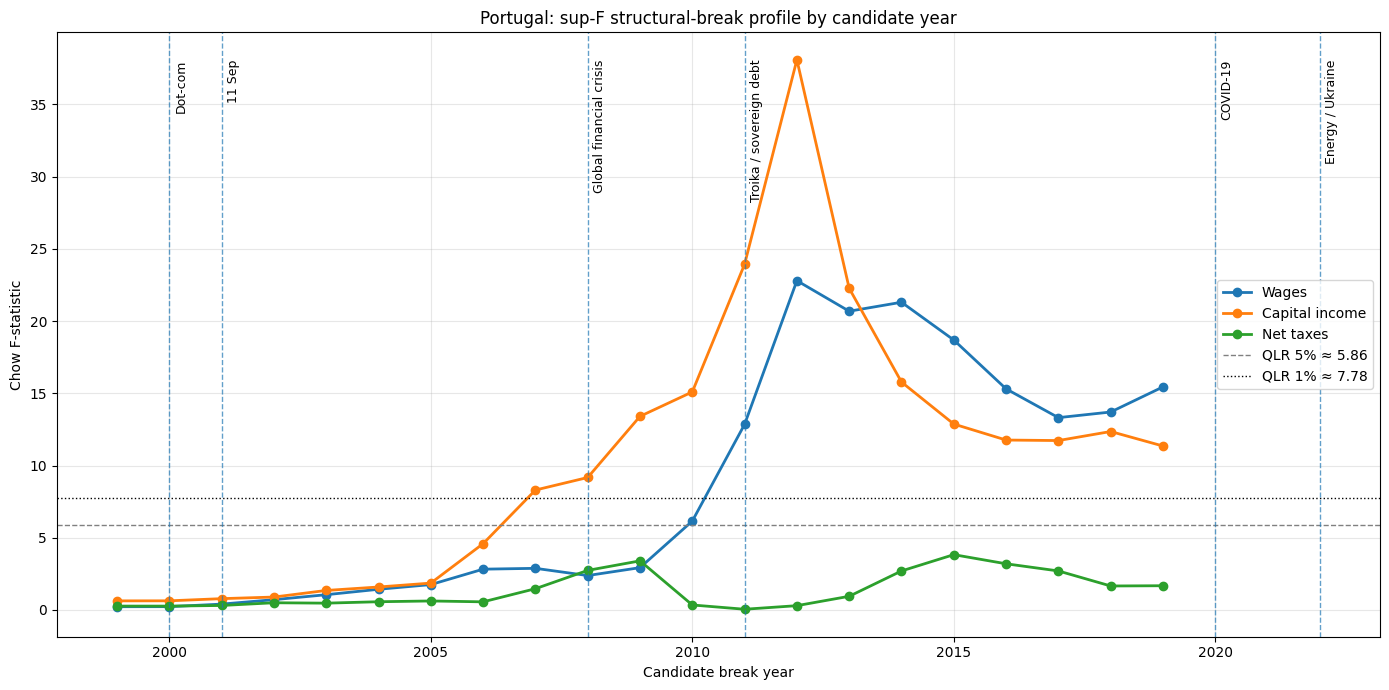

In [18]:
def plot_supf_profiles(profiles: dict[str, pd.DataFrame]) -> None:
    """
    Plot the sup-F (Quandt) break profile for each share.

    Parameters
    ----------
    profiles : dict[str, pd.DataFrame]
        Per-component sup-F profiles from `structural_break_report`.
    """
    fig, ax = plt.subplots(figsize=(14, 7))
    for label, profile in profiles.items():
        ax.plot(profile["year"], profile["f_stat"], marker="o", linewidth=2, label=label)

    ax.axhline(5.86, linestyle="--", linewidth=1, color="grey", label="QLR 5% \u2248 5.86")
    ax.axhline(7.78, linestyle=":", linewidth=1, color="black", label="QLR 1% \u2248 7.78")

    peak = max(profile["f_stat"].max() for profile in profiles.values())
    annotate_crises(ax, df, CRISIS_EVENTS, y_position=peak)

    ax.set_title("Portugal: sup-F structural-break profile by candidate year")
    ax.set_xlabel("Candidate break year")
    ax.set_ylabel("Chow F-statistic")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_supf_profiles(break_profiles)

## E. Regime comparison

We compare the pre-crisis regime (1995–2007) with the post-austerity regime (2013–2024), deliberately dropping the 2008–2012 transition. For each share we report the two means, the change in percentage points, a Welch t-test (unequal variances) and the non-parametric Mann–Whitney U test as a robustness check that does not assume normality.

In [19]:
def regime_comparison(
    df: pd.DataFrame,
    columns: dict[str, str] = SHARE_COLUMNS,
    pre_end: int = 2007,
    post_start: int = 2013,
) -> pd.DataFrame:
    """
    Compare pre- and post-crisis regime means for each share.

    Parameters
    ----------
    df : pd.DataFrame
        Income distribution dataset.
    columns : dict[str, str]
        Mapping of share column name to display label.
    pre_end : int
        Last year of the pre-crisis regime (inclusive).
    post_start : int
        First year of the post-austerity regime (inclusive).

    Returns
    -------
    pd.DataFrame
        One row per share with regime means and two-sample test p-values.
    """
    rows = []
    for column, label in columns.items():
        pre = df.loc[df["year"] <= pre_end, column]
        post = df.loc[df["year"] >= post_start, column]
        welch = stats.ttest_ind(pre, post, equal_var=False)
        mann_whitney = stats.mannwhitneyu(pre, post)
        rows.append({
            "component": label,
            f"mean_pre_{pre_end}": round(float(pre.mean()), 2),
            f"mean_post_{post_start}": round(float(post.mean()), 2),
            "change_pp": round(float(post.mean() - pre.mean()), 2),
            "welch_t_p": round(float(welch.pvalue), 4),
            "mann_whitney_p": round(float(mann_whitney.pvalue), 4),
        })
    return pd.DataFrame(rows)


regime_table = regime_comparison(df)
regime_table

,component,mean_pre_2007,mean_post_2013,change_pp,welch_t_p,mann_whitney_p
0,Wages,47.51,45.65,-1.86,0.0033,0.0155
1,Capital income,40.52,41.22,0.69,0.1526,0.4966
2,Net taxes,11.97,13.13,1.17,0.0004,0.0008


## F. Capital–wage relationship and the compositional constraint

The wage and capital shares move in near-mirror image. We quantify this with Pearson and Spearman correlations and test for a long-run equilibrium relationship with the Engle–Granger cointegration test.

A crucial caveat: the three shares sum to **exactly 100% of GDP** by accounting identity, so they are *compositional* data. Part of any negative wage–capital correlation is therefore mechanical, and a high correlation should not be over-interpreted as an independent economic comovement.

In [20]:
def capital_wage_relationship(df: pd.DataFrame) -> pd.Series:
    """
    Quantify the relationship between the capital and wage shares.

    Returns
    -------
    pd.Series
        Pearson/Spearman correlations, the Engle-Granger cointegration
        p-value, and the observed range of the three-share sum (which
        should be ~100% by construction).
    """
    capital = df["capital_income_share_pct"]
    wages = df["wages_share_pct"]
    pearson_r, pearson_p = stats.pearsonr(capital, wages)
    spearman_r, _ = stats.spearmanr(capital, wages)
    _, engle_granger_p, _ = coint(capital, wages)
    shares_sum = (
        df["wages_share_pct"] + df["capital_income_share_pct"] + df["net_taxes_share_pct"]
    )
    return pd.Series({
        "pearson_r": round(float(pearson_r), 3),
        "pearson_p": round(float(pearson_p), 4),
        "spearman_r": round(float(spearman_r), 3),
        "engle_granger_p": round(float(engle_granger_p), 3),
        "shares_sum_min": round(float(shares_sum.min()), 2),
        "shares_sum_max": round(float(shares_sum.max()), 2),
    })


relationship_summary = capital_wage_relationship(df)
relationship_summary

pearson_r           -0.800
pearson_p            0.000
spearman_r          -0.749
engle_granger_p      0.607
shares_sum_min     100.000
shares_sum_max     100.000
dtype: float64

## G. Comparison with actual GDP: levels and cyclicality

Everything so far is expressed as a *share* of GDP, which by design removes the level and the business cycle. That is exactly what we now add back. We bring in **actual GDP** in two forms:

- the **nominal GDP level** (current prices), already in the dataset; and
- **real GDP growth** (chain-linked volumes, % change on the previous year), fetched from the same Eurostat dataset.

A share can move either because the economy is in a boom or bust (a *cyclical* effect, since GDP is the denominator) or because the underlying distribution has genuinely shifted (a *structural* effect). To separate the two we regress the **year-over-year change in each share** on contemporaneous real GDP growth, with Newey–West (HAC) standard errors. A positive slope means the share is procyclical; a negative slope means countercyclical.

In [21]:
REAL_GDP_GROWTH_SERIES: Final[str] = "Eurostat/nama_10_gdp/A.CLV_PCH_PRE.B1GQ.PT"


def attach_gdp_growth(df: pd.DataFrame) -> pd.DataFrame:
    """
    Attach real and nominal GDP growth to the income distribution dataset.

    Parameters
    ----------
    df : pd.DataFrame
        Income distribution dataset (must contain `year` and `gdp`).

    Returns
    -------
    pd.DataFrame
        The input with `real_gdp_growth` (chain-linked volumes, % change on
        the previous year) and `nominal_gdp_growth` columns added.
    """
    real_growth = fetch_eurostat_series(REAL_GDP_GROWTH_SERIES, "real_gdp_growth")
    out = df.merge(real_growth, on="year", how="left")
    out["nominal_gdp_growth"] = 100.0 * out["gdp"].pct_change()
    return out


df = attach_gdp_growth(df)
df.loc[:, ["year", "gdp", "real_gdp_growth", "nominal_gdp_growth"]].tail(10)

,year,gdp,real_gdp_growth,nominal_gdp_growth
20,2015,179392.7,1.6,3.583416
21,2016,186380.7,2.0,3.895365
22,2017,195509.1,3.3,4.897717
23,2018,204997.6,2.9,4.853227
24,2019,214489.9,2.7,4.630444
25,2020,201032.7,-8.2,-6.274048
26,2021,216493.7,5.6,7.690789
27,2022,243957.1,7.0,12.685542
28,2023,270352.6,3.1,10.819730
29,2024,289428.0,2.1,7.055749


The chart below shows the actual GDP that has been sitting in the denominator: the nominal level (top) and real growth (bottom), with the same crisis markers used elsewhere. The 2009, 2011–2013, and 2020 contractions are clearly visible.

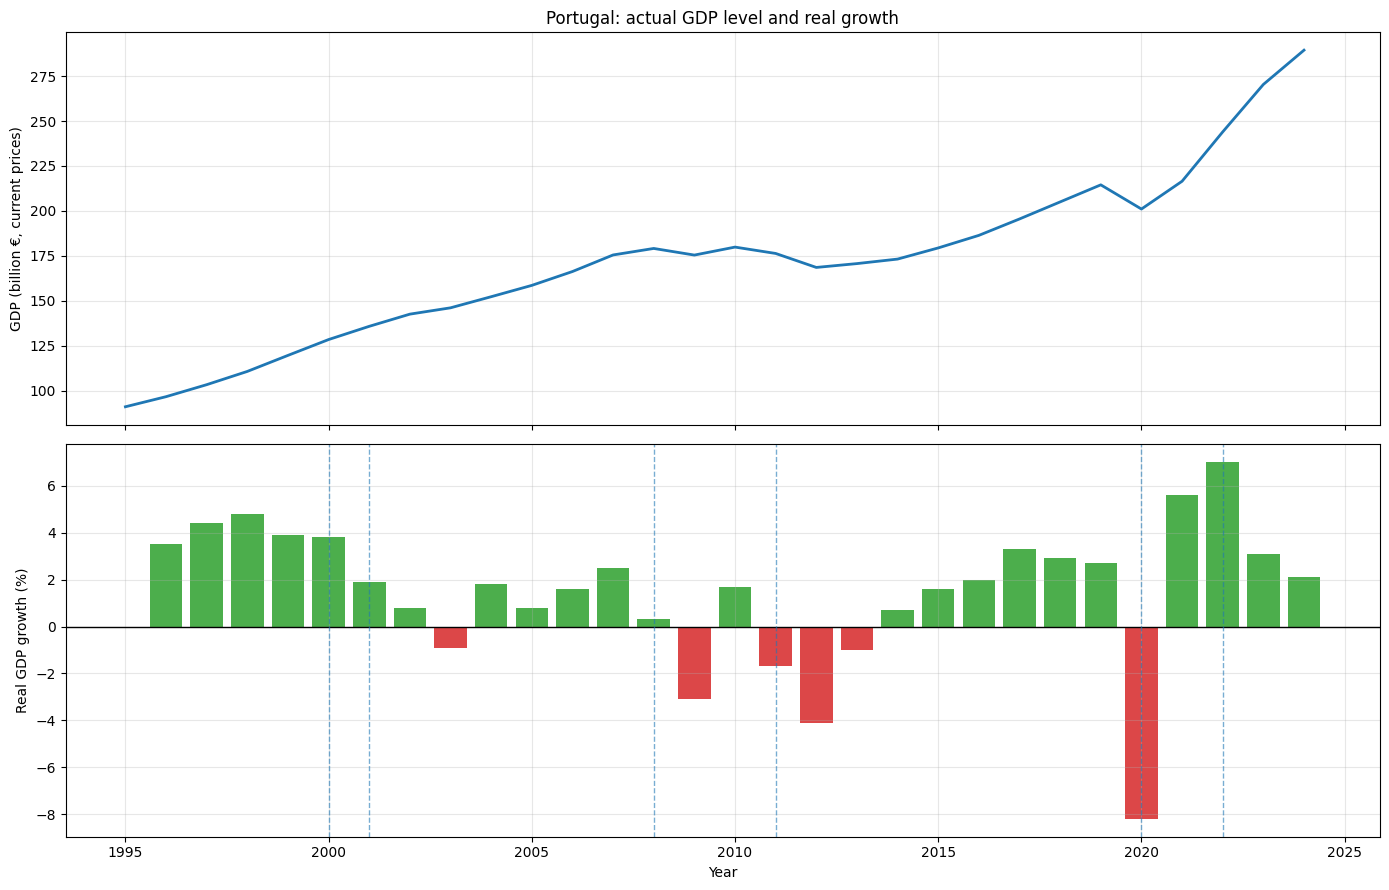

In [22]:
def plot_actual_gdp(df: pd.DataFrame) -> None:
    """
    Plot the nominal GDP level and real GDP growth over time.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset with `gdp` (current prices) and `real_gdp_growth`.
    """
    fig, (ax_level, ax_growth) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

    ax_level.plot(df["year"], df["gdp"] / 1000.0, linewidth=2)
    ax_level.set_ylabel("GDP (billion €, current prices)")
    ax_level.set_title("Portugal: actual GDP level and real growth")
    ax_level.grid(True, alpha=0.3)

    bar_colors = ["tab:green" if value >= 0 else "tab:red" for value in df["real_gdp_growth"].fillna(0)]
    ax_growth.bar(df["year"], df["real_gdp_growth"], color=bar_colors, alpha=0.85)
    ax_growth.axhline(0, linewidth=1, color="black")
    ax_growth.set_ylabel("Real GDP growth (%)")
    ax_growth.set_xlabel("Year")
    ax_growth.grid(True, alpha=0.3)

    for event in CRISIS_EVENTS:
        if int(df["year"].min()) <= event.year <= int(df["year"].max()):
            ax_growth.axvline(event.year, linestyle="--", linewidth=1, alpha=0.6)

    plt.tight_layout()
    plt.show()


plot_actual_gdp(df)

### Cyclicality of the income shares

We now test, for each share, whether its year-over-year change co-moves with real GDP growth.

In [23]:
def cyclicality_report(df: pd.DataFrame, columns: dict[str, str] = SHARE_COLUMNS, hac_lags: int = 2) -> pd.DataFrame:
    """
    Regress the change in each share on contemporaneous real GDP growth.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset with the share columns and `real_gdp_growth`.
    columns : dict[str, str]
        Mapping of share column name to display label.
    hac_lags : int
        Maximum lag for the Newey-West covariance estimator.

    Returns
    -------
    pd.DataFrame
        One row per share with the cyclicality slope, its HAC p-value, the
        Pearson correlation, R-squared, and a procyclical/countercyclical tag.
    """
    data = df.dropna(subset=["real_gdp_growth"]).copy()
    rows = []
    for column, label in columns.items():
        change = data[column].diff()
        valid = change.notna().to_numpy()
        growth = data["real_gdp_growth"].to_numpy()[valid]
        delta = change.to_numpy()[valid]
        model = sm.OLS(delta, sm.add_constant(growth)).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
        pearson_r, pearson_p = stats.pearsonr(growth, delta)
        if model.pvalues[1] < 0.10:
            tag = "procyclical" if model.params[1] > 0 else "countercyclical"
        else:
            tag = "acyclical"
        rows.append({
            "component": label,
            "slope_pp_per_1pp_growth": round(float(model.params[1]), 3),
            "hac_p_value": round(float(model.pvalues[1]), 4),
            "pearson_r": round(float(pearson_r), 3),
            "pearson_p": round(float(pearson_p), 4),
            "r_squared": round(float(model.rsquared), 3),
            "pattern": tag,
        })
    return pd.DataFrame(rows)


cyclicality_table = cyclicality_report(df)
cyclicality_table

,component,slope_pp_per_1pp_growth,hac_p_value,pearson_r,pearson_p,r_squared,pattern
0,Wages,-0.100,0.3097,-0.366,0.0551,0.134,acyclical
1,Capital income,-0.025,0.6950,-0.134,0.4965,0.018,acyclical
2,Net taxes,0.125,0.0024,0.628,0.0003,0.395,procyclical


The scatter plots make the patterns visible: each point is one year, the horizontal axis is real GDP growth and the vertical axis is the year-over-year change in the share, with an OLS line.

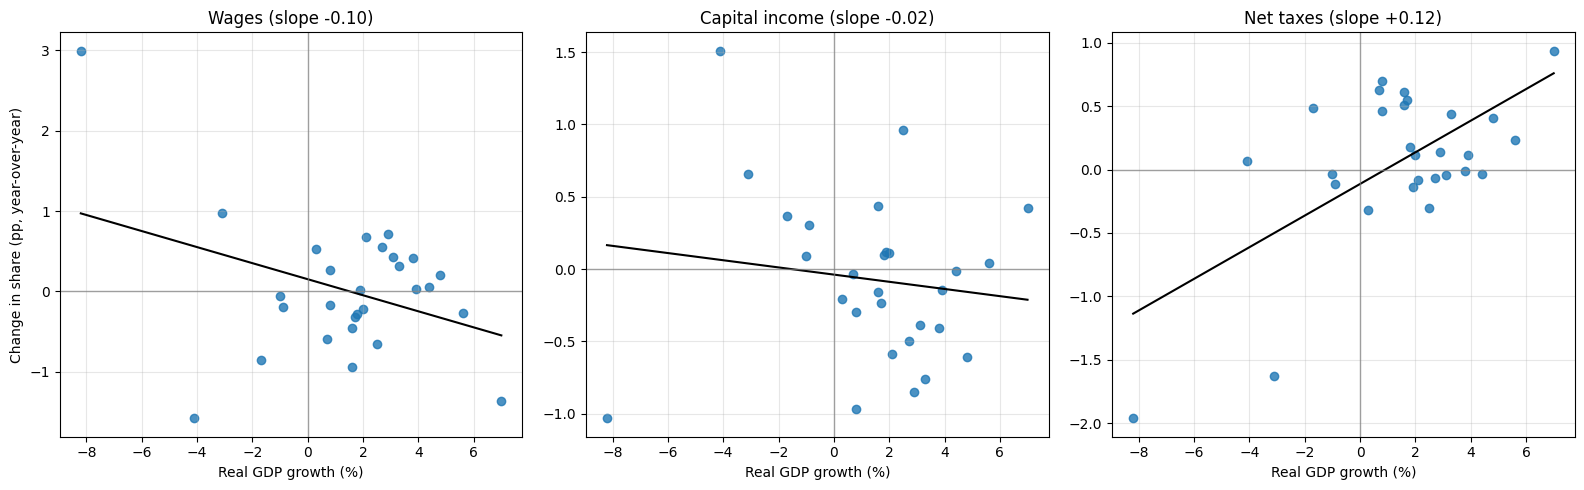

In [24]:
def plot_cyclicality(df: pd.DataFrame, columns: dict[str, str] = SHARE_COLUMNS) -> None:
    """
    Scatter the change in each share against real GDP growth, with an OLS line.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset with the share columns and `real_gdp_growth`.
    columns : dict[str, str]
        Mapping of share column name to display label.
    """
    data = df.dropna(subset=["real_gdp_growth"]).copy()
    fig, axes = plt.subplots(1, len(columns), figsize=(16, 5), sharex=True)

    for ax, (column, label) in zip(axes, columns.items()):
        change = data[column].diff()
        mask = change.notna()
        growth = data.loc[mask, "real_gdp_growth"]
        delta = change[mask]
        ax.scatter(growth, delta, alpha=0.8)
        slope, intercept = np.polyfit(growth, delta, 1)
        line_x = np.linspace(growth.min(), growth.max(), 50)
        ax.plot(line_x, intercept + slope * line_x, color="black", linewidth=1.5)
        ax.axhline(0, linewidth=1, color="grey", alpha=0.7)
        ax.axvline(0, linewidth=1, color="grey", alpha=0.7)
        ax.set_title(f"{label} (slope {slope:+.2f})")
        ax.set_xlabel("Real GDP growth (%)")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Change in share (pp, year-over-year)")
    plt.tight_layout()
    plt.show()


plot_cyclicality(df)

### What the cycle tells us about the structural break

The wage share leans **countercyclical** — its year-over-year change is negatively correlated with growth (r ≈ −0.37), but this is only borderline in the simple correlation (p ≈ 0.06) and not significant once HAC-robust standard errors are used (p ≈ 0.31), so the table tags it *acyclical*. The *sign* is still informative: in a downturn GDP (the denominator) tends to shrink faster than the wage bill, pushing the share up. That makes the post-2012 behaviour striking — the wage share *fell* through the 2013–2019 recovery, the opposite of what a countercyclical tendency would produce. The decline therefore looks structural, consistent with the sup-F break at 2012, rather than a by-product of the recession. The net-tax share, by contrast, is **robustly procyclical** (HAC p ≈ 0.002), so part of its rise simply reflects recovery; the capital share is essentially **acyclical**.

# Methodological refinements

The analysis so far leans on tools that assume away two features of this data: the shares are *compositional* (they sum to 100%) and they are *highly persistent* (near unit-root). This section tightens the inference with four refinements and one external benchmark:

- **H.1** re-expresses capital-versus-labour as an unconstrained **log-ratio**, the principled version of the earlier "capital − wages" difference.
- **H.2** retests the unit root with the **Zivot–Andrews** test, which allows one endogenous break — the right tool given the break we found.
- **H.3** quantifies the 2012 break with an **interrupted time-series** (segmented regression) instead of merely detecting it.
- **H.4** stress-tests the break's significance with a **persistence-aware AR(1) bootstrap**, since asymptotic sup-F critical values assume stationary errors.
- **H.5** benchmarks Portugal against the **euro area**.

In [25]:
from statsmodels.tsa.stattools import zivot_andrews

ITS_BREAK_YEAR: Final[int] = 2012      # candidate structural break (Troika adjustment)
SUPF_TRIM: Final[float] = 0.15         # symmetric trimming for the sup-F scan
BOOTSTRAP_REPS: Final[int] = 999       # AR(1) bootstrap replications
BOOTSTRAP_SEED: Final[int] = 20240101  # fixed seed for reproducibility

## H.1 Compositional treatment: the log capital-to-labour ratio

Because the shares are constrained to sum to 100%, differences between them (such as the earlier "capital − wages" chart) mix real movement with the mechanical constraint. The standard fix from compositional data analysis is to work with a **log-ratio**, which is unconstrained and symmetric:

\[
\text{log K/L} = \log\!\left(\frac{\text{capital share}}{\text{wage share}}\right)
\]

A rising series means capital is gaining on labour. We add it to the dataset and estimate its trend with HAC-robust standard errors.

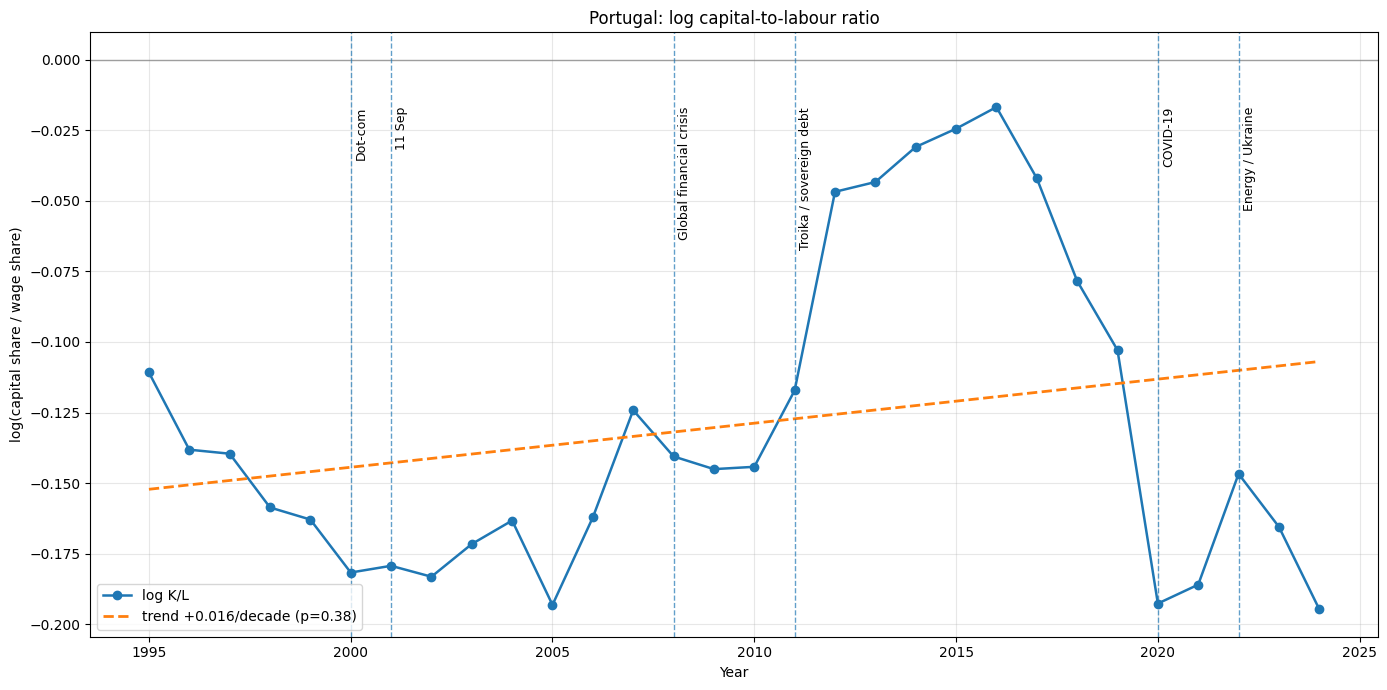

In [26]:
df["log_capital_labour"] = np.log(df["capital_income_share_pct"] / df["wages_share_pct"])

LOGRATIO_COLUMNS: Final[dict[str, str]] = {**SHARE_COLUMNS, "log_capital_labour": "log K/L"}


def plot_log_capital_labour(df: pd.DataFrame) -> None:
    """Plot the log capital-to-labour ratio with its HAC-robust linear trend."""
    elapsed = (df["year"] - df["year"].min()).to_numpy()
    model = sm.OLS(df["log_capital_labour"].to_numpy(), sm.add_constant(elapsed)).fit(
        cov_type="HAC", cov_kwds={"maxlags": 3}
    )
    fitted = model.params[0] + model.params[1] * elapsed

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(df["year"], df["log_capital_labour"], marker="o", linewidth=1.8, label="log K/L")
    ax.plot(df["year"], fitted, linestyle="--", linewidth=2,
            label=f"trend {model.params[1] * 10:+.3f}/decade (p={model.pvalues[1]:.2f})")
    ax.axhline(0, linewidth=1, color="grey", alpha=0.7)
    annotate_crises(ax, df, CRISIS_EVENTS, y_position=float(df["log_capital_labour"].max()))
    ax.set_title("Portugal: log capital-to-labour ratio")
    ax.set_xlabel("Year")
    ax.set_ylabel("log(capital share / wage share)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_log_capital_labour(df)

Over the full sample the log-ratio has **no significant trend** (slope ≈ +0.016 per decade, HAC p ≈ 0.38): capital has not secularly gained on labour. Its visible movement is the 2012 spike — when the wage bill collapsed faster than gross operating surplus — followed by a partial reversal. This reframes the story as an *episode*, not a trend.

## H.2 Unit root with an endogenous break (Zivot–Andrews)

A standard ADF test loses power when the series contains a structural break, which can make a broken-but-stationary series look like a unit root. The **Zivot–Andrews** test guards against this by searching for the single break date that most favours rejecting the unit-root null. If we *still* cannot reject, the persistence finding from section B is robust.

In [27]:
def zivot_andrews_report(df: pd.DataFrame, columns: dict[str, str] = LOGRATIO_COLUMNS) -> pd.DataFrame:
    """
    Run the Zivot-Andrews unit-root test (intercept break) for each series.

    Returns
    -------
    pd.DataFrame
        One row per series with the ZA statistic, p-value, the 5% critical
        value, the estimated break year, and the unit-root verdict.
    """
    years = df["year"].reset_index(drop=True)
    rows = []
    for column, label in columns.items():
        series = df[column].dropna().to_numpy()
        try:
            za_stat, za_p, crit, _, break_idx = zivot_andrews(
                series, regression="c", maxlag=1, trim=SUPF_TRIM
            )
            rows.append({
                "series": label,
                "za_stat": round(float(za_stat), 2),
                "za_p_value": round(float(za_p), 3),
                "crit_5pct": round(float(crit["5%"]), 2),
                "za_break_year": int(years.iloc[break_idx]),
                "unit_root_rejected": bool(za_p < 0.05),
            })
        except Exception as error:  # noqa: BLE001 - short series can trip the routine
            rows.append({"series": label, "za_stat": None, "za_p_value": None,
                         "crit_5pct": None, "za_break_year": None, "unit_root_rejected": None})
    return pd.DataFrame(rows)


zivot_andrews_table = zivot_andrews_report(df)
zivot_andrews_table

,series,za_stat,za_p_value,crit_5pct,za_break_year,unit_root_rejected
0,Wages,-4.22,0.228,-4.81,2019,False
1,Capital income,-2.76,0.961,-4.81,2017,False
2,Net taxes,-3.87,0.434,-4.81,2019,False
3,log K/L,-2.99,0.914,-4.81,2019,False


For every series the Zivot–Andrews statistic stays well above its 5% critical value (≈ −4.8), so even allowing an endogenous break we **cannot reject a unit root** (p ≈ 0.2–0.96). The near-random-walk behaviour is genuine, not an artefact of an unmodelled break. Note that the ZA break date is whatever best helps reject the null and need not coincide with the *mean* break studied next — the two tests answer different questions.

## H.3 Quantifying the break: interrupted time series

Detecting a break is not the same as measuring it. An **interrupted time-series** (segmented regression) fits a trend that is allowed to jump in level and change slope at the break year:

\[
y_t = \beta_0 + \beta_1 t + \beta_2 \, \mathbb{1}[t \ge 2012] + \beta_3 (t - 2012)^{+} + \varepsilon_t
\]

so \(\beta_2\) is the immediate **level shift** and \(\beta_3\) is the **slope change**, both with HAC-robust inference.

In [28]:
def interrupted_time_series(
    df: pd.DataFrame,
    columns: dict[str, str] = LOGRATIO_COLUMNS,
    break_year: int = ITS_BREAK_YEAR,
    hac_lags: int = 3,
) -> tuple[pd.DataFrame, dict[str, np.ndarray]]:
    """
    Fit a segmented (level + slope change) regression at `break_year` per series.

    Returns
    -------
    tuple[pd.DataFrame, dict[str, np.ndarray]]
        A coefficient table and, per series, the fitted values for plotting.
    """
    elapsed = (df["year"] - df["year"].min()).to_numpy()
    post = (df["year"] >= break_year).astype(float).to_numpy()
    time_since = (df["year"] - break_year).clip(lower=0).to_numpy()
    design = np.column_stack([np.ones_like(elapsed), elapsed, post, time_since])

    rows, fitted_values = [], {}
    for column, label in columns.items():
        outcome = df[column].to_numpy()
        model = sm.OLS(outcome, design).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
        rows.append({
            "series": label,
            "pre_slope": round(float(model.params[1]), 3),
            "level_shift": round(float(model.params[2]), 3),
            "level_shift_p": round(float(model.pvalues[2]), 4),
            "slope_change": round(float(model.params[3]), 3),
            "slope_change_p": round(float(model.pvalues[3]), 4),
            "r_squared": round(float(model.rsquared), 3),
        })
        fitted_values[label] = model.fittedvalues
    return pd.DataFrame(rows), fitted_values


its_table, its_fitted = interrupted_time_series(df)
its_table

,series,pre_slope,level_shift,level_shift_p,slope_change,slope_change_p,r_squared
0,Wages,-0.043,-3.364,0.0000,0.365,0.0000,0.702
1,Capital income,-0.020,3.030,0.0000,-0.338,0.0000,0.746
2,Net taxes,0.063,0.334,0.5437,-0.027,0.6857,0.490
3,log K/L,0.000,0.147,0.0000,-0.016,0.0000,0.748


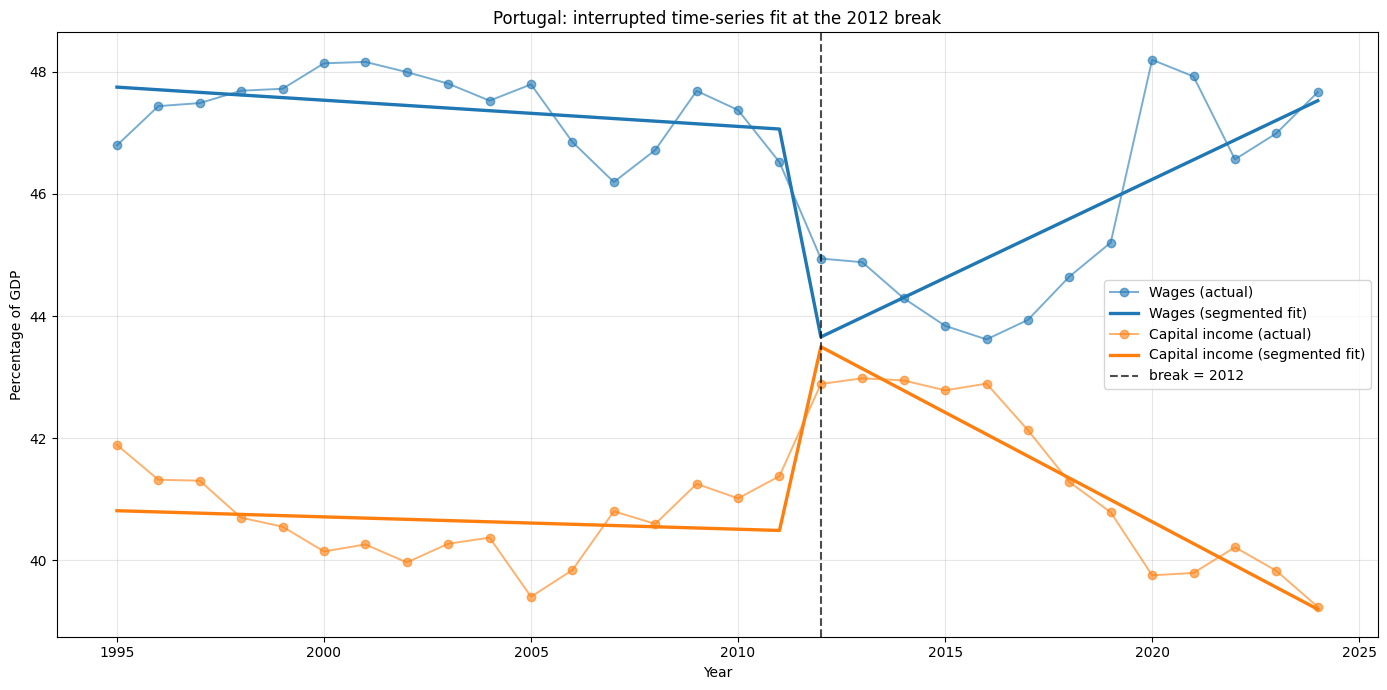

In [29]:
def plot_interrupted_time_series(df: pd.DataFrame, fitted_values: dict[str, np.ndarray]) -> None:
    """Overlay the segmented fit on the wage and capital shares."""
    fig, ax = plt.subplots(figsize=(14, 7))
    for column, label, colour in [
        ("wages_share_pct", "Wages", "tab:blue"),
        ("capital_income_share_pct", "Capital income", "tab:orange"),
    ]:
        ax.plot(df["year"], df[column], marker="o", linewidth=1.4, color=colour, alpha=0.6, label=f"{label} (actual)")
        ax.plot(df["year"], fitted_values[label], linewidth=2.4, color=colour, label=f"{label} (segmented fit)")

    ax.axvline(ITS_BREAK_YEAR, linestyle="--", linewidth=1.5, color="black", alpha=0.7,
               label=f"break = {ITS_BREAK_YEAR}")
    ax.set_title("Portugal: interrupted time-series fit at the 2012 break")
    ax.set_xlabel("Year")
    ax.set_ylabel("Percentage of GDP")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_interrupted_time_series(df, its_fitted)

The segmented model is decisive about the *shape* of the episode: at 2012 the wage share drops **−3.4 pp** and the capital share jumps **+3.0 pp** (both p < 0.001), each followed by a slope reversal that partly unwinds the move. Adding the break lifts R² from ≈ 0.18 (linear trend) to ≈ 0.70–0.75. Net taxes show no significant shift, confirming the dislocation was a labour-versus-capital reallocation.

## H.4 How robust is the break? A persistence-aware bootstrap

The sup-F critical values in section D assume stationary, serially uncorrelated errors. Our residuals are neither. We therefore simulate the **null of no break** directly: fit a linear trend with AR(1) errors, generate many surrogate series with the same persistence (ρ ≈ 0.85), and ask how often a purely persistent series produces a sup-F as large as the one we observed.

In [30]:
def _ols_ssr(outcome: np.ndarray, design: np.ndarray) -> float:
    """Residual sum of squares via least squares (fast inner-loop helper)."""
    beta, _, _, _ = np.linalg.lstsq(design, outcome, rcond=None)
    residual = outcome - design @ beta
    return float(residual @ residual)


def _supf_statistic(outcome: np.ndarray, design: np.ndarray, trim: float = SUPF_TRIM) -> float:
    """Maximum Chow F-statistic over candidate break dates in the central window."""
    n_obs, n_params = len(outcome), design.shape[1]
    low, high = int(trim * n_obs), int((1 - trim) * n_obs)
    best = 0.0
    for split in range(low, high):
        pooled = _ols_ssr(outcome, design)
        left = _ols_ssr(outcome[:split], design[:split])
        right = _ols_ssr(outcome[split:], design[split:])
        f_stat = ((pooled - (left + right)) / n_params) / ((left + right) / (n_obs - 2 * n_params))
        best = max(best, f_stat)
    return best


def bootstrap_break_pvalue(
    df: pd.DataFrame,
    columns: dict[str, str] = LOGRATIO_COLUMNS,
    reps: int = BOOTSTRAP_REPS,
    seed: int = BOOTSTRAP_SEED,
) -> pd.DataFrame:
    """
    AR(1) parametric-bootstrap p-value for the sup-F break statistic.

    Under the null of no break, the series is a linear trend plus AR(1) noise.
    We resample that process `reps` times and compare each surrogate's sup-F to
    the observed one, giving a p-value robust to the strong serial correlation
    that invalidates the asymptotic sup-F critical values.
    """
    rng = np.random.default_rng(seed)
    elapsed = (df["year"] - df["year"].min()).to_numpy()
    design = sm.add_constant(elapsed)
    n_obs = len(elapsed)
    rows = []
    for column, label in columns.items():
        outcome = df[column].to_numpy()
        fit = sm.OLS(outcome, design).fit()
        residual = np.asarray(fit.resid)
        fitted = np.asarray(fit.fittedvalues)
        lagged, current = residual[:-1], residual[1:]
        rho = float(lagged @ current / (lagged @ lagged))
        rho = min(max(rho, -0.99), 0.99)
        innovation_sd = (current - rho * lagged).std(ddof=1)
        observed = _supf_statistic(outcome, design)

        exceedances = 0
        for _ in range(reps):
            noise = np.empty(n_obs)
            noise[0] = rng.normal(0.0, innovation_sd / np.sqrt(1 - rho ** 2))
            for i in range(1, n_obs):
                noise[i] = rho * noise[i - 1] + rng.normal(0.0, innovation_sd)
            if _supf_statistic(fitted + noise, design) >= observed:
                exceedances += 1
        rows.append({
            "series": label,
            "supF_observed": round(observed, 2),
            "ar1_rho": round(rho, 2),
            "bootstrap_p_value": round((exceedances + 1) / (reps + 1), 3),
        })
    return pd.DataFrame(rows)


bootstrap_break_table = bootstrap_break_pvalue(df)
bootstrap_break_table

,series,supF_observed,ar1_rho,bootstrap_p_value
0,Wages,22.80,0.82,0.216
1,Capital income,38.09,0.89,0.110
2,Net taxes,3.83,0.56,0.868
3,log K/L,35.50,0.88,0.124


This is the section's most important correction. Under the asymptotic test the break looked overwhelming (sup-F ≈ 23–38 versus a 1% cut-off of 7.8). Once we respect the persistence, the bootstrap p-values rise to **≈ 0.11–0.22** — *not* significant at conventional levels, because a random walk wanders enough to mimic a break in a 30-point sample. The honest reading: the 2012 reallocation is **economically clear** (right timing, large effect size, and it runs against the wage share's countercyclical tendency) but **statistically only suggestive** given the short, persistent sample.

## H.5 External benchmark: Portugal vs the euro area

Is Portugal's capital–labour split unusual? We fetch the same components for the euro area and compare the log K/L ratio.

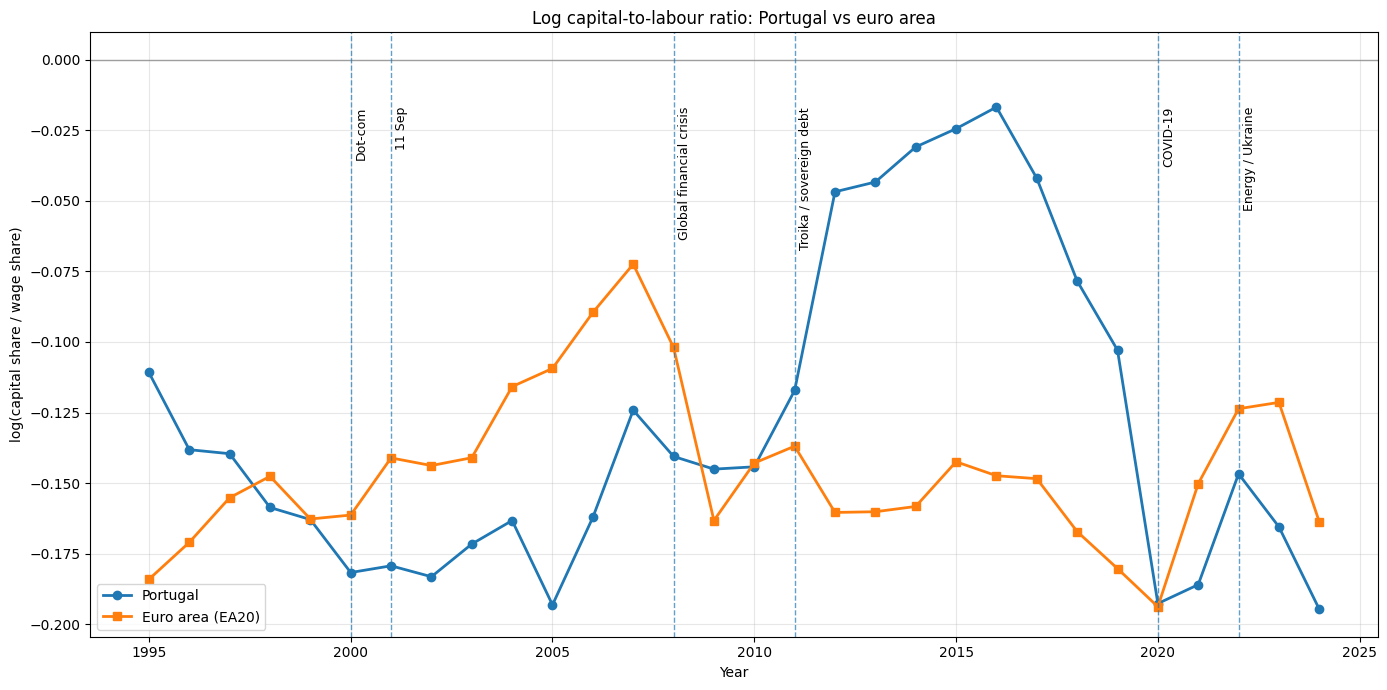

In [31]:
EA_WAGES_SERIES: Final[str] = "Eurostat/nama_10_gdp/A.CP_MEUR.D1.EA20"
EA_CAPITAL_SERIES: Final[str] = "Eurostat/nama_10_gdp/A.CP_MEUR.B2A3G.EA20"


def build_euro_area_log_ratio() -> pd.DataFrame:
    """Build the euro-area (EA20) log capital-to-labour ratio."""
    ea_wages = fetch_eurostat_series(EA_WAGES_SERIES, "ea_wages")
    ea_capital = fetch_eurostat_series(EA_CAPITAL_SERIES, "ea_capital")
    ea = ea_wages.merge(ea_capital, on="year", how="inner")
    ea["ea_log_capital_labour"] = np.log(ea["ea_capital"] / ea["ea_wages"])
    return ea.loc[:, ["year", "ea_log_capital_labour"]]


def plot_portugal_vs_euro_area(df: pd.DataFrame, ea: pd.DataFrame) -> None:
    """Compare the Portuguese and euro-area log capital-to-labour ratios."""
    comparison = df.loc[:, ["year", "log_capital_labour"]].merge(ea, on="year", how="inner")
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(comparison["year"], comparison["log_capital_labour"], marker="o", linewidth=2, label="Portugal")
    ax.plot(comparison["year"], comparison["ea_log_capital_labour"], marker="s", linewidth=2, label="Euro area (EA20)")
    ax.axhline(0, linewidth=1, color="grey", alpha=0.7)
    annotate_crises(ax, comparison, CRISIS_EVENTS, y_position=float(comparison["log_capital_labour"].max()))
    ax.set_title("Log capital-to-labour ratio: Portugal vs euro area")
    ax.set_xlabel("Year")
    ax.set_ylabel("log(capital share / wage share)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


euro_area_log_ratio = build_euro_area_log_ratio()
plot_portugal_vs_euro_area(df, euro_area_log_ratio)

The euro-area log K/L ratio is essentially flat at about −0.18 (capital ≈ 83% of labour). Portugal tracks it closely but with a higher-amplitude 2012 episode and a slightly more labour-tilted endpoint — the Troika adjustment moved Portugal's functional distribution by more than the euro-area average, then largely reverted.

## Statistical findings

Bringing the sections together:

1. **Stable but persistent shares.** All three shares have a low coefficient of variation (≈3% for wages and capital, ≈7% for net taxes), yet they behave like **I(1) processes**: ADF cannot reject a unit root in levels while first differences are stationary, and Durbin–Watson statistics of 0.3–0.9 confirm strong persistence. A **Zivot–Andrews** test that allows one endogenous break *still* cannot reject a unit root (H.2), so the persistence is genuine rather than an artefact of the 2012 shift. Level-on-time regressions are therefore fragile.

2. **Only net taxes show a genuine trend.** The net-tax share rises ≈ +0.7 pp per decade (HAC p < 0.001, R² ≈ 0.48), consistent with higher indirect taxation. The wage-share slope is negative but insignificant (≈ −0.7 pp/decade, p ≈ 0.11) and the capital share is flat (p ≈ 0.96). Re-expressed as the unconstrained **log capital-to-labour ratio**, there is likewise no significant secular trend (p ≈ 0.38): capital has not durably gained on labour.

3. **A 2012 reallocation — clear in size, fragile in significance.** The sup-F scan and Chow tests point sharply at **2012**, and an **interrupted time-series** model puts the dislocation at **−3.4 pp for wages and +3.0 pp for capital** (both p < 0.001), each partly reversing afterwards and lifting R² to ≈ 0.7. *However*, a persistence-aware **AR(1) bootstrap** of the sup-F statistic returns p ≈ **0.11–0.22** (H.4): a near-unit-root series can mimic a break in 30 points, so the asymptotic test overstated the evidence. We read the 2012 episode as economically clear (timing, effect size, and the countercyclical argument) but statistically only suggestive. Net taxes show no break.

4. **The wage share's loss accrued to taxes, not capital.** Between the 1995–2007 and 2013–2024 regimes the wage share fell **−1.9 pp** (Welch p ≈ 0.003) and the net-tax share rose **+1.2 pp** (p < 0.001), while the capital share barely moved (+0.7 pp, not significant). The post-crisis redistribution went largely to indirect taxes.

5. **The cycle matters, but the break is structural in character.** Net taxes are robustly **procyclical** (HAC p ≈ 0.002); the wage share leans **countercyclical** in sign (r ≈ −0.37) though not HAC-significant; capital is **acyclical**. The wage share kept falling through the 2013–2019 recovery — against its countercyclical tendency — which supports a structural (austerity) reading of the 2012 move.

6. **The capital–wage mirror is partly mechanical, and barely maps to household inequality.** The shares sum to 100% by construction, so the −0.80 capital–wage correlation is partly an identity, and Engle–Granger finds no cointegration beyond it (p ≈ 0.61). Linking the functional split to *personal* inequality is weak and window-dependent: a positive capital-share–Gini association appears only in the short 2014–2024 window (r ≈ +0.72) and vanishes over the longer S80/S20 and poverty series.

7. **Living standards improved regardless of the factor split.** Real GDP per capita grew +1.25%/yr, life expectancy +2.6 years/decade, and both poverty and inequality declined — a reminder that the functional distribution is only one, loosely-coupled input into welfare.

**Limitations.** With only 30 annual observations the unit-root and break tests have limited power and — most importantly — the structural-break date is statistically fragile once serial correlation is respected (H.4): effect sizes and timing are more reliable than formal break significance. The sup-F/QLR thresholds are non-standard; the capital proxy blends labour and capital income through gross mixed income; the survey-based inequality series are short (Gini from 2014); and correlations between the functional and personal distributions are descriptive, not causal.

# Living standards and inequality

The functional distribution tells us how GDP is split between labour and capital, but not how well people actually live. A share can shift without anyone being better or worse off. This part widens the lens to **welfare-relevant** indicators, then asks whether the factor split (functional distribution) has any bearing on the **personal** distribution of income.

We add three families of indicators, all from Eurostat via DBnomics:

| Family | Indicator | Series |
|---|---|---|
| Output per person | Real GDP per capita (chain-linked, 2020 €) | `nama_10_pc` `CLV20_EUR_HAB` |
| Output per person | GDP per capita in PPS (vs EU27) | `nama_10_pc` `CP_PPS_EU27_2020_HAB` |
| Demography | Average population | `demo_gind` `AVG` |
| Demography | Life expectancy at birth | `demo_mlexpec` |
| Labour | Unemployment rate (15–74) | `une_rt_a` |
| Inequality | Gini of equivalised disposable income | `ilc_di12` |
| Inequality | Income quintile share ratio (S80/S20) | `ilc_di11` |
| Poverty | At-risk-of-poverty rate (60% median) | `ilc_li02` |
| Poverty | At-risk-of-poverty-or-social-exclusion | `ilc_peps01n` |

The survey-based inequality series (Gini, AROPE) start only in the 2010s, so their windows are short; the poverty rate and per-capita output span the full 1995–2024 period.

In [32]:
SOCIAL_SERIES: Final[dict[str, str]] = {
    "real_gdp_per_capita": "Eurostat/nama_10_pc/A.CLV20_EUR_HAB.B1GQ.PT",
    "gdp_per_capita_pps": "Eurostat/nama_10_pc/A.CP_PPS_EU27_2020_HAB.B1GQ.PT",
    "population": "Eurostat/demo_gind/A.AVG.PT",
    "life_expectancy": "Eurostat/demo_mlexpec/A.YR.T.Y_LT1.PT",
    "unemployment_rate": "Eurostat/une_rt_a/A.Y15-74.PC_ACT.T.PT",
    "gini": "Eurostat/ilc_di12/A.TOTAL.GINI_HND.PT",
    "income_quintile_ratio_s80s20": "Eurostat/ilc_di11/A.TOTAL.T.RAT.PT",
    "at_risk_of_poverty_rate": "Eurostat/ilc_li02/A.PC.LI_R_MD60.T.TOTAL.PT",
    "at_risk_poverty_or_exclusion": "Eurostat/ilc_peps01n/A.PC.TOTAL.T.PT",
}


def build_social_dataframe(start_year: int = START_YEAR) -> pd.DataFrame:
    """
    Fetch and merge the living-standard and inequality indicators.

    Parameters
    ----------
    start_year : int
        First year to keep.

    Returns
    -------
    pd.DataFrame
        Annual DataFrame with one column per indicator (outer-joined on year).
    """
    frame: pd.DataFrame | None = None
    for name, series_code in SOCIAL_SERIES.items():
        indicator = fetch_eurostat_series(series_code, name)
        frame = indicator if frame is None else frame.merge(indicator, on="year", how="outer")
    frame = frame[frame["year"] >= start_year].sort_values("year").reset_index(drop=True)
    return frame


social_df = build_social_dataframe()
social_df.set_index("year").notna().sum().rename("non_null_years").to_frame().T

,real_gdp_per_capita,gdp_per_capita_pps,population,life_expectancy,unemployment_rate,gini,income_quintile_ratio_s80s20,at_risk_of_poverty_rate,at_risk_poverty_or_exclusion
non_null_years,30,30,30,30,16,11,21,29,10


## A wellbeing dashboard

Six panels: material output (real GDP per capita and PPS vs EU), demography (population and life expectancy), labour (unemployment), and the distribution (inequality and poverty).

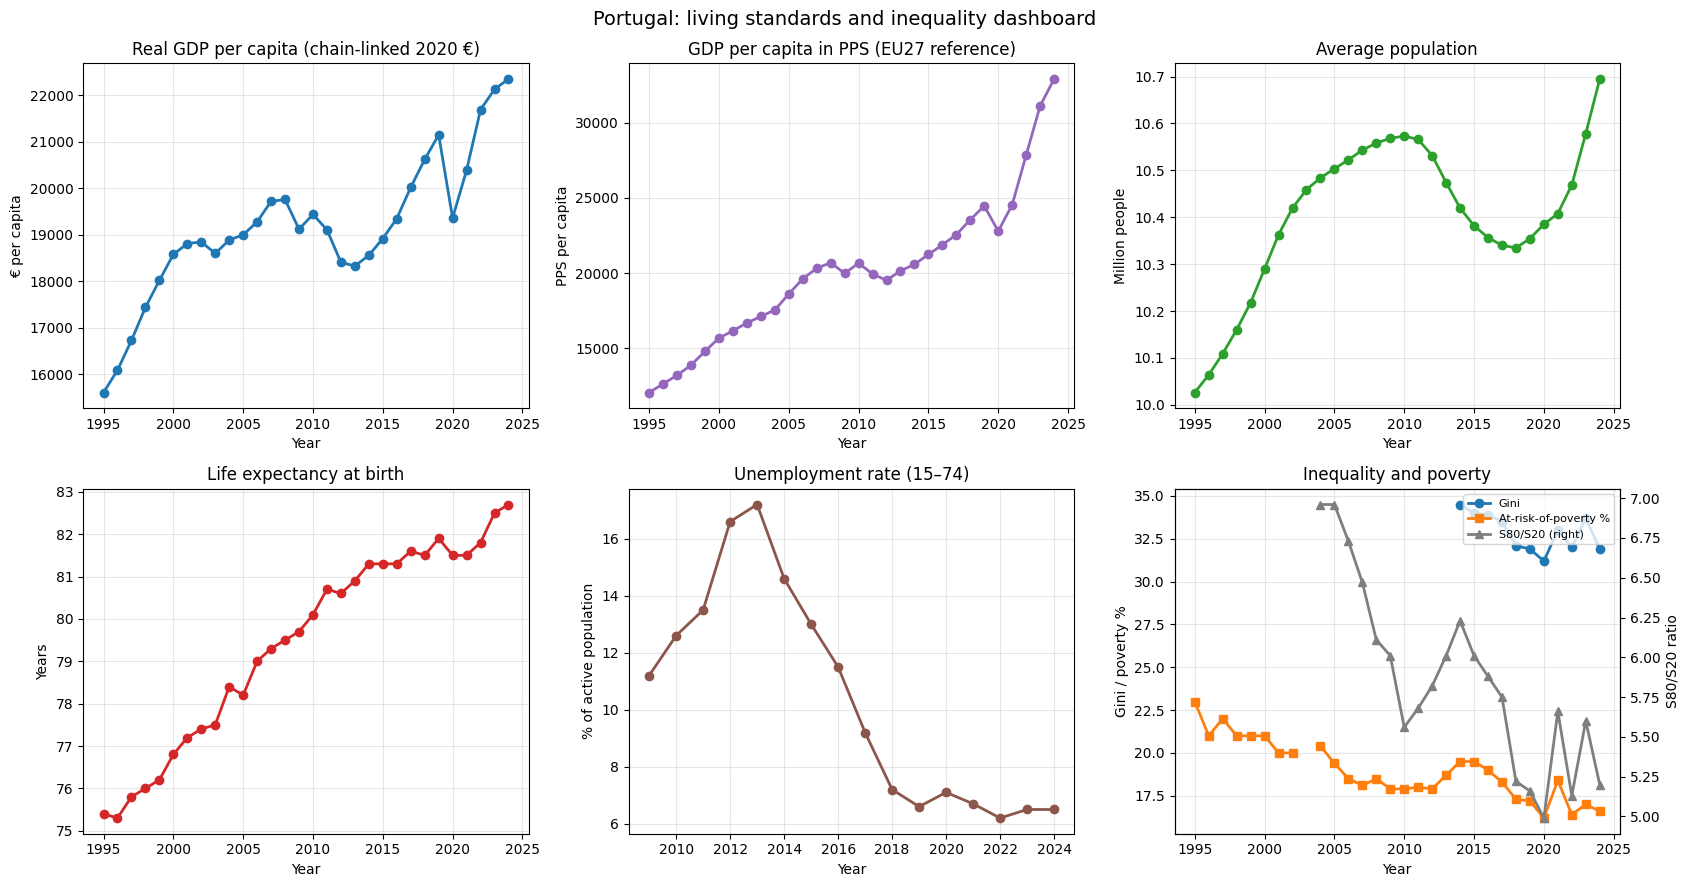

In [33]:
def plot_wellbeing_dashboard(social_df: pd.DataFrame) -> None:
    """Plot a 2x3 dashboard of living-standard and inequality indicators."""
    fig, axes = plt.subplots(2, 3, figsize=(17, 9))

    ax = axes[0, 0]
    ax.plot(social_df["year"], social_df["real_gdp_per_capita"], marker="o", linewidth=2)
    ax.set_title("Real GDP per capita (chain-linked 2020 €)")
    ax.set_ylabel("€ per capita")

    ax = axes[0, 1]
    ax.plot(social_df["year"], social_df["gdp_per_capita_pps"], marker="o", linewidth=2, color="tab:purple")
    ax.set_title("GDP per capita in PPS (EU27 reference)")
    ax.set_ylabel("PPS per capita")

    ax = axes[0, 2]
    ax.plot(social_df["year"], social_df["population"] / 1e6, marker="o", linewidth=2, color="tab:green")
    ax.set_title("Average population")
    ax.set_ylabel("Million people")

    ax = axes[1, 0]
    ax.plot(social_df["year"], social_df["life_expectancy"], marker="o", linewidth=2, color="tab:red")
    ax.set_title("Life expectancy at birth")
    ax.set_ylabel("Years")

    ax = axes[1, 1]
    ax.plot(social_df["year"], social_df["unemployment_rate"], marker="o", linewidth=2, color="tab:brown")
    ax.set_title("Unemployment rate (15–74)")
    ax.set_ylabel("% of active population")

    ax = axes[1, 2]
    ax.plot(social_df["year"], social_df["gini"], marker="o", linewidth=2, label="Gini")
    ax.plot(social_df["year"], social_df["at_risk_of_poverty_rate"], marker="s", linewidth=2, label="At-risk-of-poverty %")
    twin = ax.twinx()
    twin.plot(social_df["year"], social_df["income_quintile_ratio_s80s20"], marker="^", linewidth=2,
              color="tab:gray", label="S80/S20 (right)")
    ax.set_title("Inequality and poverty")
    ax.set_ylabel("Gini / poverty %")
    twin.set_ylabel("S80/S20 ratio")
    lines = ax.get_lines() + twin.get_lines()
    ax.legend(lines, [line.get_label() for line in lines], fontsize=8, loc="upper right")

    for row in axes:
        for ax in row:
            ax.set_xlabel("Year")
            ax.grid(True, alpha=0.3)

    fig.suptitle("Portugal: living standards and inequality dashboard", fontsize=14)
    plt.tight_layout()
    plt.show()


plot_wellbeing_dashboard(social_df)

## Trends in living standards

We summarise each indicator with a HAC-robust linear trend (per decade) over its available window, plus the cumulative change and, for real GDP per capita, the compound annual growth rate.

In [34]:
def social_trend_report(
    social_df: pd.DataFrame,
    indicators: tuple[str, ...] = (
        "real_gdp_per_capita", "life_expectancy", "unemployment_rate",
        "gini", "income_quintile_ratio_s80s20", "at_risk_of_poverty_rate",
    ),
) -> pd.DataFrame:
    """Estimate a HAC-robust per-decade trend for each living-standard indicator."""
    rows = []
    for indicator in indicators:
        data = social_df.dropna(subset=[indicator])
        elapsed = (data["year"] - data["year"].min()).to_numpy()
        model = sm.OLS(data[indicator].to_numpy(), sm.add_constant(elapsed)).fit(
            cov_type="HAC", cov_kwds={"maxlags": 3}
        )
        first_value, last_value = float(data[indicator].iloc[0]), float(data[indicator].iloc[-1])
        rows.append({
            "indicator": indicator,
            "start_year": int(data["year"].iloc[0]),
            "end_year": int(data["year"].iloc[-1]),
            "n": int(len(data)),
            "first": round(first_value, 2),
            "last": round(last_value, 2),
            "change": round(last_value - first_value, 2),
            "slope_per_decade": round(float(model.params[1]) * 10, 3),
            "hac_p_value": round(float(model.pvalues[1]), 4),
        })
    table = pd.DataFrame(rows)

    gdp = social_df.dropna(subset=["real_gdp_per_capita"])
    span = int(gdp["year"].iloc[-1] - gdp["year"].iloc[0])
    cagr = (gdp["real_gdp_per_capita"].iloc[-1] / gdp["real_gdp_per_capita"].iloc[0]) ** (1 / span) - 1
    print(f"Real GDP per capita CAGR {gdp['year'].iloc[0]}-{gdp['year'].iloc[-1]}: {cagr * 100:.2f}% per year")
    return table


social_trend_table = social_trend_report(social_df)
social_trend_table

Real GDP per capita CAGR 1995-2024: 1.25% per year


,indicator,start_year,end_year,n,first,last,change,slope_per_decade,hac_p_value
0,real_gdp_per_capita,1995,2024,30,15610.00,22350.0,6740.00,1483.804,0.000
1,life_expectancy,1995,2024,30,75.40,82.7,7.30,2.580,0.000
2,unemployment_rate,2009,2024,16,11.20,6.5,-4.70,-6.612,0.000
3,gini,2014,2024,11,34.50,31.9,-2.60,-1.982,0.006
4,income_quintile_ratio_s80s20,2004,2024,21,6.96,5.2,-1.76,-0.783,0.000
5,at_risk_of_poverty_rate,1995,2024,29,23.00,16.6,-6.40,-1.696,0.000


Every welfare indicator improved over the sample: real GDP per capita grew at **+1.25% per year**, life expectancy rose about **+2.6 years per decade**, and all three distribution measures fell — the at-risk-of-poverty rate dropped from **23% (1995) to 16.6% (2024)** (−1.7 pp/decade, p < 0.001), with the Gini and S80/S20 ratio declining in their shorter windows. On these measures, Portugal became richer, healthier, and somewhat more equal — a different and more welfare-relevant story than the functional shares alone.

## Does the functional distribution shape household inequality?

A natural hypothesis is that a higher **capital** share concentrates income (capital income is more unequally held) and so raises **personal** inequality. We test it by correlating the functional shares with the household measures over their overlapping years. We treat this as descriptive: the two distributions are conceptually distinct, the windows are short, and correlation is not causation.

In [35]:
def distribution_link_report(
    df: pd.DataFrame,
    social_df: pd.DataFrame,
    inequality_columns: tuple[str, ...] = ("gini", "income_quintile_ratio_s80s20", "at_risk_of_poverty_rate"),
) -> pd.DataFrame:
    """Correlate functional shares with household inequality measures."""
    merged = df.merge(social_df, on="year", how="inner")
    rows = []
    for inequality in inequality_columns:
        valid = merged.dropna(subset=[inequality, "capital_income_share_pct"])
        entry = {"inequality_measure": inequality, "n": int(len(valid))}
        for share, key in [
            ("capital_income_share_pct", "capital_share"),
            ("wages_share_pct", "wage_share"),
            ("log_capital_labour", "log_K_L"),
        ]:
            r, p = stats.pearsonr(valid[share], valid[inequality])
            entry[f"{key}_r"] = round(float(r), 2)
            entry[f"{key}_p"] = round(float(p), 3)
        rows.append(entry)
    return pd.DataFrame(rows)


distribution_link_table = distribution_link_report(df, social_df)
distribution_link_table

,inequality_measure,n,capital_share_r,capital_share_p,wage_share_r,wage_share_p,log_K_L_r,log_K_L_p
0,gini,11,0.72,0.013,-0.60,0.049,0.67,0.025
1,income_quintile_ratio_s80s20,21,0.05,0.828,0.05,0.829,-0.00,0.991
2,at_risk_of_poverty_rate,29,0.18,0.341,0.20,0.288,-0.02,0.901


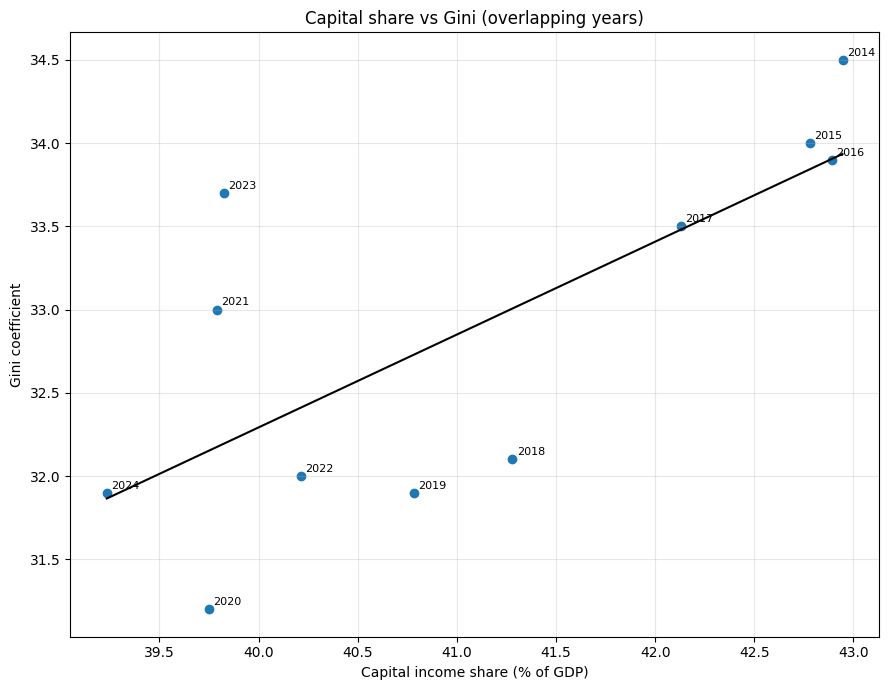

In [36]:
def plot_capital_share_vs_gini(df: pd.DataFrame, social_df: pd.DataFrame) -> None:
    """Scatter the capital share against the Gini over their overlapping years."""
    merged = df.merge(social_df, on="year", how="inner").dropna(subset=["gini"])
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.scatter(merged["capital_income_share_pct"], merged["gini"])
    for _, row in merged.iterrows():
        ax.annotate(int(row["year"]), (row["capital_income_share_pct"], row["gini"]),
                    fontsize=8, xytext=(3, 3), textcoords="offset points")
    slope, intercept = np.polyfit(merged["capital_income_share_pct"], merged["gini"], 1)
    line_x = np.linspace(merged["capital_income_share_pct"].min(), merged["capital_income_share_pct"].max(), 50)
    ax.plot(line_x, intercept + slope * line_x, color="black", linewidth=1.5)
    ax.set_title("Capital share vs Gini (overlapping years)")
    ax.set_xlabel("Capital income share (% of GDP)")
    ax.set_ylabel("Gini coefficient")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_capital_share_vs_gini(df, social_df)

The link is **weak and inconsistent**. In the short recent Gini window (n ≈ 11) a higher capital share does go with higher inequality (r ≈ +0.72, p ≈ 0.01) and a higher wage share with lower inequality (r ≈ −0.60) — the textbook direction. But over the longer S80/S20 (n ≈ 21) and at-risk-of-poverty (n ≈ 29) windows the correlation collapses to roughly zero (p > 0.3). So the factor split is, at best, a partial and recent correlate of household inequality in Portugal — taxes, transfers, household composition, and employment do most of the work mapping the functional distribution into what families actually receive. This is a caution against reading capital-versus-labour shares directly as a measure of how unequal a society is.

## Exporting the results

This cell saves the full table and the summary table to CSV.

In [37]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

artifacts = {
    "portugal_gdp_income_distribution.csv": df,
    "portugal_gdp_income_distribution_summary.csv": summary,
    "stat_descriptive.csv": descriptive_table,
    "stat_stationarity.csv": stationarity_table,
    "stat_trend.csv": trend_table,
    "stat_structural_breaks.csv": break_table,
    "stat_regime_comparison.csv": regime_table,
    "stat_cyclicality.csv": cyclicality_table,
    "stat_zivot_andrews.csv": zivot_andrews_table,
    "stat_interrupted_time_series.csv": its_table,
    "stat_bootstrap_break.csv": bootstrap_break_table,
    "living_standards.csv": social_df,
    "social_trends.csv": social_trend_table,
    "distribution_inequality_link.csv": distribution_link_table,
}

for filename, table in artifacts.items():
    path = OUTPUT_DIR / filename
    table.to_csv(path, index=False)
    print(f"Saved: {path}")

Saved: outputs\portugal_gdp_income_distribution.csv
Saved: outputs\portugal_gdp_income_distribution_summary.csv
Saved: outputs\stat_descriptive.csv
Saved: outputs\stat_stationarity.csv
Saved: outputs\stat_trend.csv
Saved: outputs\stat_structural_breaks.csv
Saved: outputs\stat_regime_comparison.csv
Saved: outputs\stat_cyclicality.csv
Saved: outputs\stat_zivot_andrews.csv
Saved: outputs\stat_interrupted_time_series.csv
Saved: outputs\stat_bootstrap_break.csv
Saved: outputs\living_standards.csv
Saved: outputs\social_trends.csv
Saved: outputs\distribution_inequality_link.csv


## Interpretation

This analysis lets us observe the functional distribution of Portuguese GDP from the income side.

The **wages** component measures the compensation paid to employees.

The **capital** component is approximated here by gross operating surplus and gross mixed income.

The **taxes net of subsidies** component represents the part of GDP associated with taxes on production and imports after subsidies are deducted.

One important caveat: gross mixed income does not perfectly separate labour and capital. This matters in economies with self-employed workers, small businesses, and sole proprietorships. For that reason, the capital series used here is a macroeconomic proxy, not a pure measure of corporate profits.

The crises marked on the chart should not be read as direct causality. They serve as historical references. Causal inference would require a different empirical design.

## Possible next extensions

Building on what the notebook now contains (a euro-area benchmark, structural-break and bootstrap inference, and the living-standards block), natural continuations are:

1. widen the cross-country panel to Spain, Italy, Greece and the EU27, and test whether the 2012 break is shared or Portugal-specific;
2. swap GDP for GVA to remove net taxes from the base, isolating the labour–capital split;
3. decompose by institutional sector (non-financial corporations, households, government) and by industry, where the mixed-income/labour ambiguity is smaller;
4. model the wage share jointly with unemployment and the output gap (e.g. a small VAR) to separate cyclical from structural drivers more formally;
5. replace the single-break tests with a Bai–Perron multiple-break estimator and report break-date confidence intervals;
6. trace the functional distribution into personal inequality through the tax-and-transfer system (market vs disposable Gini), which the weak raw correlation suggests is where the action is.